DATASET 1: UK BOUNDARY - AUTOMATED DOWNLOAD
✓ Download successful!


/tmp/ipykernel_15510/2301938295.py:54: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  uk_gdf.to_file(output_path)
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Shape__Area' to 'Shape__Are'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Shape__Length' to 'Shape__Len'
  ogr_write(


✓ Saved to: smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp

Dataset info:
  Number of countries: 4
  Countries: ['England', 'Northern Ireland', 'Scotland', 'Wales']
  CRS: EPSG:4326

Validating downloaded data...
✓ Validation map saved to: smr_site_selection/results/validation_uk_boundary.png


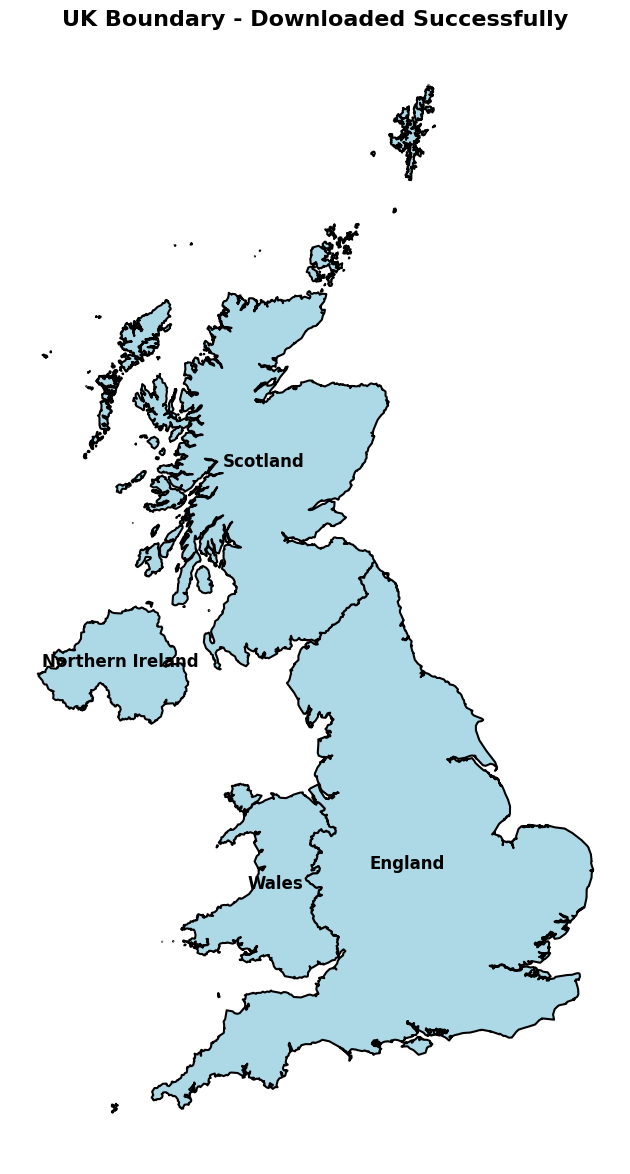


✅ DATASET 1 COMPLETE

You can now proceed with the analysis!


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

"""
Download UK Boundary Data - Direct API Method
==============================================

This script downloads UK boundary data directly from the ONS API
No manual download needed!
"""

import requests
import json
import geopandas as gpd
from shapely.geometry import shape
import os

def download_uk_boundary():
    """
    Download UK countries boundary from ONS Open Geography Portal API
    """
    print("Downloading UK boundary data from ONS API...")

    # ONS Open Geography Portal API endpoint for Countries
    # This gets the December 2023 UK boundaries (generalized for fast rendering)
    url = "https://services1.arcgis.com/ESMARspQHYMw9BZ9/arcgis/rest/services/Countries_December_2023_Boundaries_UK_BUC/FeatureServer/0/query"

    params = {
        'where': '1=1',  # Get all features
        'outFields': '*',  # Get all attributes
        'f': 'geojson'  # GeoJSON format
    }

    # Make the request
    response = requests.get(url, params=params)

    if response.status_code == 200:
        print("✓ Download successful!")

        # Parse GeoJSON
        geojson_data = response.json()

        # Convert to GeoDataFrame
        uk_gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])

        # Set coordinate reference system (WGS84)
        uk_gdf.crs = 'EPSG:4326'

        # Create directory if it doesn't exist
        os.makedirs('smr_site_selection/data/raw/boundaries', exist_ok=True)

        # Save as shapefile
        output_path = 'smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp'
        uk_gdf.to_file(output_path)

        print(f"✓ Saved to: {output_path}")
        print(f"\nDataset info:")
        print(f"  Number of countries: {len(uk_gdf)}")
        print(f"  Countries: {uk_gdf['CTRY23NM'].tolist()}")
        print(f"  CRS: {uk_gdf.crs}")

        return uk_gdf
    else:
        print(f"❌ Download failed with status code: {response.status_code}")
        return None


def validate_download():
    """
    Validate the downloaded data with a quick visualization
    """
    import matplotlib.pyplot as plt

    print("\nValidating downloaded data...")

    # Load the shapefile we just created
    uk = gpd.read_file('smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp')

    # Convert to British National Grid for proper UK projection
    uk = uk.to_crs('EPSG:27700')

    # Create validation plot
    fig, ax = plt.subplots(figsize=(10, 12))
    uk.plot(ax=ax, edgecolor='black', facecolor='lightblue', linewidth=1.5)

    # Add country labels
    for idx, row in uk.iterrows():
        centroid = row.geometry.centroid
        ax.annotate(row['CTRY23NM'],
                   xy=(centroid.x, centroid.y),
                   ha='center',
                   fontsize=12,
                   fontweight='bold')

    ax.set_title('UK Boundary - Downloaded Successfully', fontsize=16, fontweight='bold')
    ax.axis('off')

    plt.tight_layout()

    # Save validation plot
    os.makedirs('smr_site_selection/results', exist_ok=True)
    plt.savefig('smr_site_selection/results/validation_uk_boundary.png', dpi=150, bbox_inches='tight')
    print("✓ Validation map saved to: smr_site_selection/results/validation_uk_boundary.png")

    plt.show()


if __name__ == "__main__":
    print("="*60)
    print("DATASET 1: UK BOUNDARY - AUTOMATED DOWNLOAD")
    print("="*60)

    uk_gdf = download_uk_boundary()

    if uk_gdf is not None:
        validate_download()
        print("\n" + "="*60)
        print("✅ DATASET 1 COMPLETE")
        print("="*60)
        print("\nYou can now proceed with the analysis!")
    else:
        print("\n❌ Download failed. Try the alternative method below:")
        print("\nALTERNATIVE: Use Natural Earth Data")
        print("pip install naturalearth")
        print("Then run: naturalearth countries")

DATASET 2 & 3

LOADING DATASET 2: NUCLEAR SITES
CSV not found. Creating data manually...
✓ Created nuclear sites dataset from embedded data

Loaded 19 nuclear sites
Sites by status:
Status
Decommissioning       8
Operational           5
Planned               1
Under Construction    1
Recently Closed       1
Reprocessing          1
Enrichment            1
Fuel Manufacturing    1
Name: count, dtype: int64
✓ Saved as shapefile: data/processed/nuclear_sites.shp

LOADING DATASET 3: INDUSTRIAL SITES
CSV not found. Creating data manually...
✓ Created industrial sites dataset from embedded data

Loaded 15 industrial sites
Sites by cluster:
Cluster
Humber         5
Teesside       4
South Wales    2
Grangemouth    2
Southampton    1
Merseyside     1
Name: count, dtype: int64

Heat demand distribution:
Heat_Demand_Category
Very High    7
High         6
Medium       2
Name: count, dtype: int64
✓ Saved as shapefile: data/processed/industrial_sites.shp

CREATING VALIDATION MAPS


/tmp/ipykernel_15510/152098635.py:121: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  industrial_gdf.to_file('smr_site_selection/data/processed/industrial_sites.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Industry_Type' to 'Industry_T'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Heat_Demand_Category' to 'Heat_Deman'
  ogr_write(


✓ Validation map saved to: results/datasets_2_3_validation.png


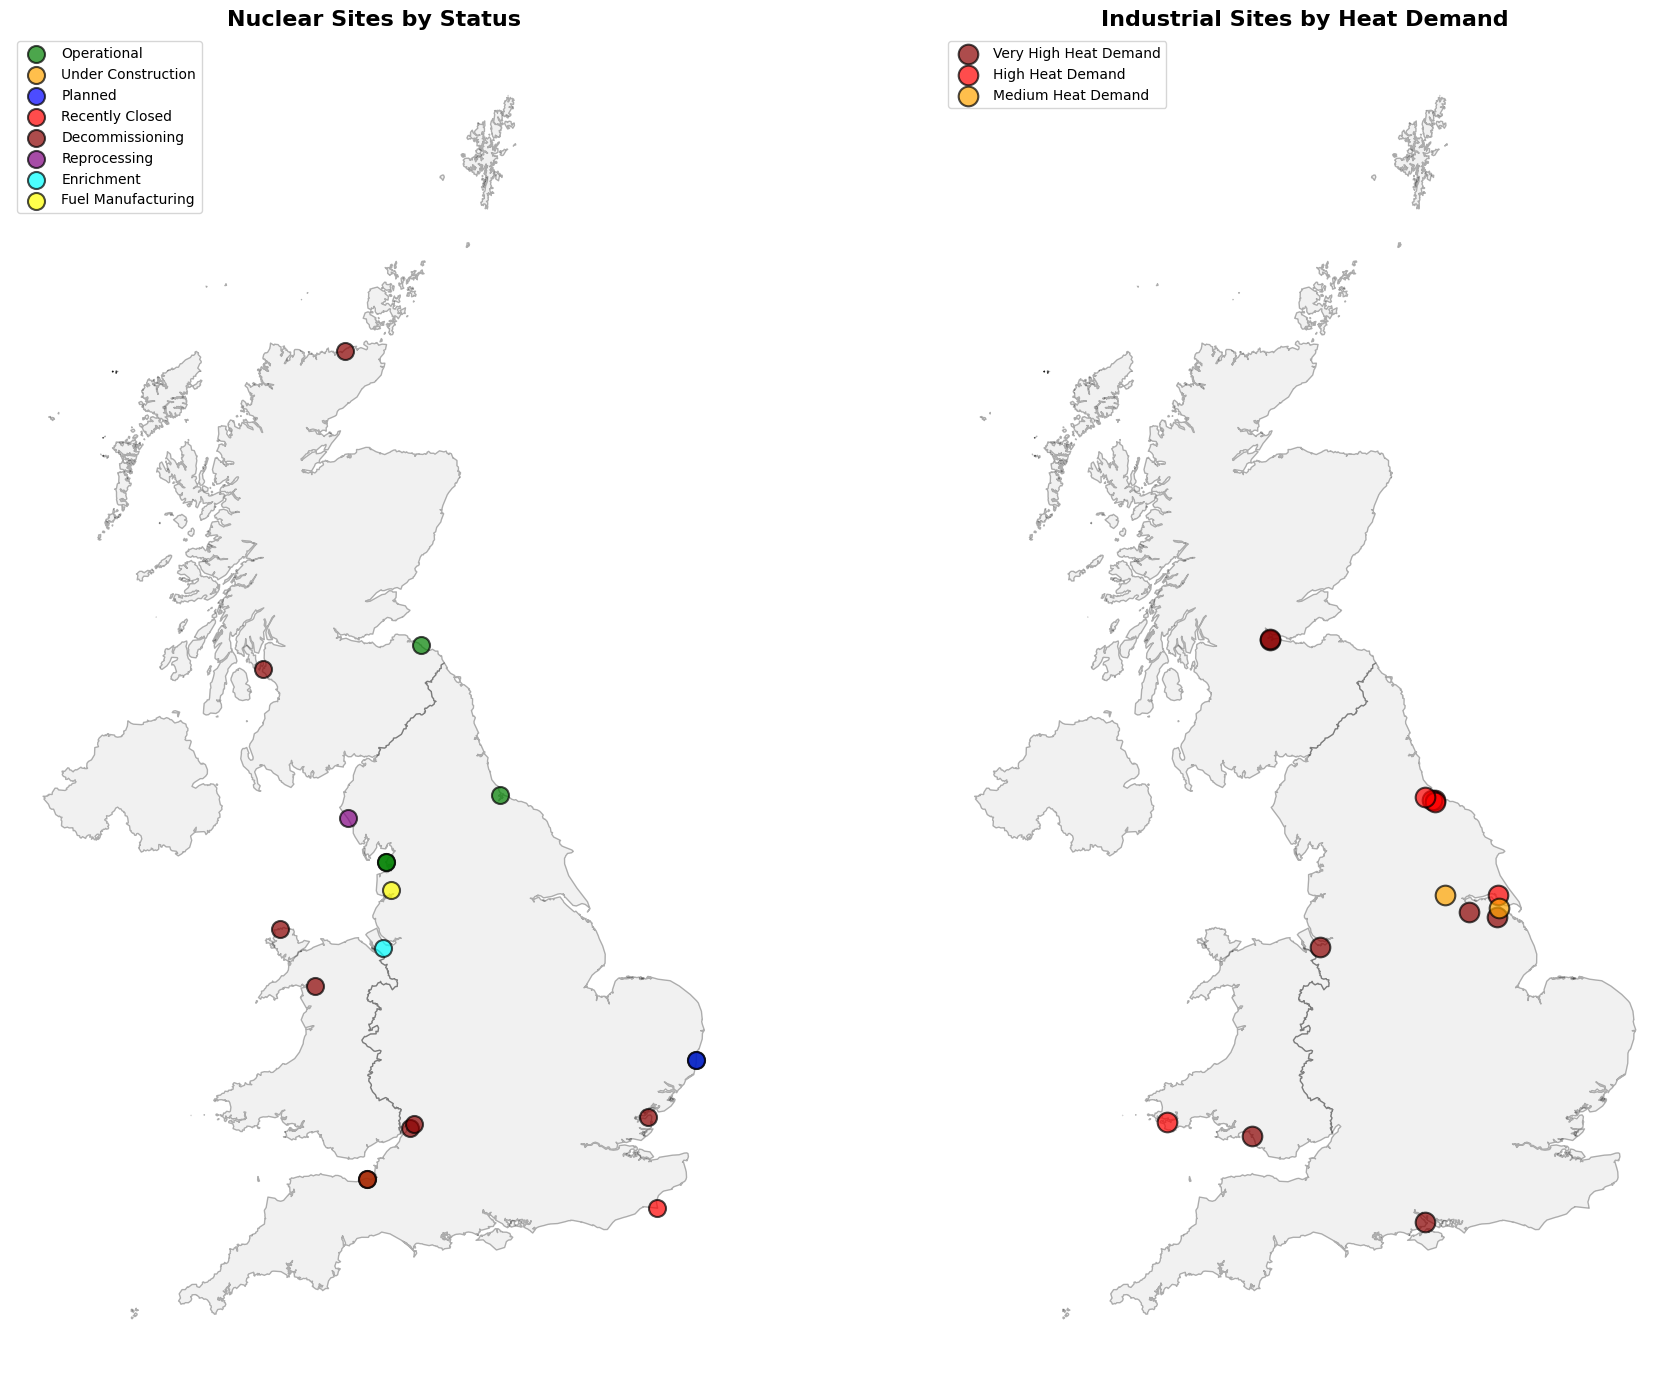


DATASETS 2 & 3 SUMMARY

NUCLEAR SITES:
  Total sites: 19
  Operational reactors: 5
  Under construction/planned: 2
  Decommissioning sites: 8

INDUSTRIAL SITES:
  Total sites: 15
  Very High heat demand: 7
  Major clusters: 6
  Top clusters: Humber, Teesside, South Wales

✅ DATASETS 2 & 3 COMPLETE!

Files created:
  - smr_site_selection/data/processed/nuclear_sites.shp
  - smr_site_selection/data/processed/industrial_sites.shp
  - smr_site_selection/results/datasets_2_3_validation.png


In [ ]:
"""
DATASETS 2 & 3: Nuclear Sites and Industrial Sites
===================================================
This script loads the CSV templates and converts them to geospatial data
"""

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import os

# Create necessary directories
os.makedirs('smr_site_selection/data/processed', exist_ok=True)
os.makedirs('smr_site_selection/results', exist_ok=True)

print("="*70)
print("LOADING DATASET 2: NUCLEAR SITES")
print("="*70)

# DATASET 2: Nuclear Sites
# ------------------------

# You'll need to upload the nuclear_sites_template.csv to Colab first
# Or paste the data directly (I'll show you how below)

# Option 1: If you uploaded the CSV file
try:
    nuclear_df = pd.read_csv('nuclear_sites_template.csv')
    print("✓ Loaded from uploaded CSV file")
except:
    print("CSV not found. Creating data manually...")

    # Option 2: Create the data directly in code
    nuclear_data = {
        'Site_Name': ['Sizewell B', 'Torness', 'Heysham 1', 'Heysham 2', 'Hartlepool',
                      'Hinkley Point C', 'Sizewell C', 'Dungeness B', 'Hunterston B',
                      'Hinkley Point B', 'Oldbury', 'Wylfa', 'Trawsfynydd', 'Berkeley',
                      'Bradwell', 'Sellafield', 'Dounreay', 'Capenhurst', 'Springfields'],
        'Status': ['Operational', 'Operational', 'Operational', 'Operational', 'Operational',
                   'Under Construction', 'Planned', 'Recently Closed', 'Decommissioning',
                   'Decommissioning', 'Decommissioning', 'Decommissioning', 'Decommissioning',
                   'Decommissioning', 'Decommissioning', 'Reprocessing', 'Decommissioning',
                   'Enrichment', 'Fuel Manufacturing'],
        'Type': ['PWR', 'AGR', 'AGR', 'AGR', 'AGR', 'EPR', 'EPR', 'AGR', 'AGR', 'AGR',
                 'Magnox', 'Magnox', 'Magnox', 'Magnox', 'Magnox', 'Complex', 'Fast Breeder',
                 'Fuel', 'Fuel'],
        'Latitude': [52.2137, 55.9697, 54.0294, 54.0294, 54.6358, 51.2067, 52.2137, 50.9133,
                     55.7244, 51.2067, 51.6636, 53.4147, 52.9167, 51.6969, 51.7236, 54.4200,
                     58.5786, 53.2667, 53.7833],
        'Longitude': [1.6207, -2.4117, -2.9181, -2.9181, -1.1817, -3.1317, 1.6207, 0.9647,
                      -4.9003, -3.1317, -2.5189, -4.4783, -3.9333, -2.4644, 0.8944, -3.5103,
                      -3.7242, -2.9500, -2.8333]
    }
    nuclear_df = pd.DataFrame(nuclear_data)
    print("✓ Created nuclear sites dataset from embedded data")

print(f"\nLoaded {len(nuclear_df)} nuclear sites")
print(f"Sites by status:\n{nuclear_df['Status'].value_counts()}")

# Convert to GeoDataFrame
geometry = [Point(lon, lat) for lon, lat in zip(nuclear_df['Longitude'], nuclear_df['Latitude'])]
nuclear_gdf = gpd.GeoDataFrame(nuclear_df, geometry=geometry, crs='EPSG:4326')

# Convert to British National Grid (EPSG:27700)
nuclear_gdf = nuclear_gdf.to_crs('EPSG:27700')

# Save as shapefile
nuclear_gdf.to_file('smr_site_selection/data/processed/nuclear_sites.shp')
print("✓ Saved as shapefile: data/processed/nuclear_sites.shp")

print("\n" + "="*70)
print("LOADING DATASET 3: INDUSTRIAL SITES")
print("="*70)

# DATASET 3: Industrial Sites
# ----------------------------

try:
    industrial_df = pd.read_csv('industrial_sites_template.csv')
    print("✓ Loaded from uploaded CSV file")
except:
    print("CSV not found. Creating data manually...")

    # Create industrial sites data
    industrial_data = {
        'Site_Name': ['Grangemouth Refinery', 'Fawley Refinery', 'Stanlow Refinery',
                      'Lindsey Oil Refinery', 'Pembroke Refinery', 'Port Talbot Steelworks',
                      'Scunthorpe Steelworks', 'Teesside Steelworks', 'INEOS Grangemouth',
                      'SABIC Teesside', 'Wilton Complex', 'CF Fertilisers Billingham',
                      'Drax Power Station', 'Immingham Port', 'Saltend Chemicals Park'],
        'Industry_Type': ['Petrochemical', 'Petrochemical', 'Petrochemical', 'Petrochemical',
                          'Petrochemical', 'Steel', 'Steel', 'Steel', 'Chemicals', 'Chemicals',
                          'Chemicals', 'Chemicals', 'Power', 'Logistics/Industrial', 'Chemicals'],
        'Cluster': ['Grangemouth', 'Southampton', 'Merseyside', 'Humber', 'South Wales',
                    'South Wales', 'Humber', 'Teesside', 'Grangemouth', 'Teesside',
                    'Teesside', 'Teesside', 'Humber', 'Humber', 'Humber'],
        'Heat_Demand_Category': ['Very High', 'Very High', 'Very High', 'Very High', 'High',
                                 'Very High', 'Very High', 'High', 'Very High', 'High',
                                 'High', 'High', 'Medium', 'Medium', 'High'],
        'Latitude': [56.0067, 50.8217, 53.2750, 53.5333, 51.6833, 51.5833, 53.5833,
                     54.5833, 56.0167, 54.5833, 54.5667, 54.6167, 53.7367, 53.6167, 53.7333],
        'Longitude': [-3.7167, -1.3350, -2.8583, -0.2167, -5.0333, -3.8000, -0.6333,
                      -1.1333, -3.7167, -1.1667, -1.1333, -1.2833, -0.9983, -0.1833, -0.2000]
    }
    industrial_df = pd.DataFrame(industrial_data)
    print("✓ Created industrial sites dataset from embedded data")

print(f"\nLoaded {len(industrial_df)} industrial sites")
print(f"Sites by cluster:\n{industrial_df['Cluster'].value_counts()}")
print(f"\nHeat demand distribution:\n{industrial_df['Heat_Demand_Category'].value_counts()}")

# Convert to GeoDataFrame
geometry = [Point(lon, lat) for lon, lat in zip(industrial_df['Longitude'], industrial_df['Latitude'])]
industrial_gdf = gpd.GeoDataFrame(industrial_df, geometry=geometry, crs='EPSG:4326')

# Convert to British National Grid
industrial_gdf = industrial_gdf.to_crs('EPSG:27700')

# Save as shapefile
industrial_gdf.to_file('smr_site_selection/data/processed/industrial_sites.shp')
print("✓ Saved as shapefile: data/processed/industrial_sites.shp")

print("\n" + "="*70)
print("CREATING VALIDATION MAPS")
print("="*70)

# Load UK boundary for context
uk = gpd.read_file('smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp')
uk = uk.to_crs('EPSG:27700')

# Create combined visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 14))

# PLOT 1: Nuclear Sites
uk.plot(ax=ax1, edgecolor='black', facecolor='lightgray', alpha=0.3)

colors_nuclear = {
    'Operational': 'green',
    'Under Construction': 'orange',
    'Planned': 'blue',
    'Recently Closed': 'red',
    'Decommissioning': 'darkred',
    'Reprocessing': 'purple',
    'Enrichment': 'cyan',
    'Fuel Manufacturing': 'yellow'
}

for status, color in colors_nuclear.items():
    subset = nuclear_gdf[nuclear_gdf['Status'] == status]
    if len(subset) > 0:
        subset.plot(ax=ax1, color=color, markersize=150, label=status,
                   alpha=0.7, edgecolor='black', linewidth=1.5)

ax1.set_title('Nuclear Sites by Status', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.axis('off')

# PLOT 2: Industrial Sites
uk.plot(ax=ax2, edgecolor='black', facecolor='lightgray', alpha=0.3)

heat_colors = {
    'Very High': 'darkred',
    'High': 'red',
    'Medium': 'orange'
}

for heat_level, color in heat_colors.items():
    subset = industrial_gdf[industrial_gdf['Heat_Demand_Category'] == heat_level]
    if len(subset) > 0:
        subset.plot(ax=ax2, color=color, markersize=200, label=f'{heat_level} Heat Demand',
                   alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.set_title('Industrial Sites by Heat Demand', fontsize=16, fontweight='bold')
ax2.legend(loc='upper left', fontsize=10)
ax2.axis('off')

plt.tight_layout()
plt.savefig('smr_site_selection/results/datasets_2_3_validation.png', dpi=150, bbox_inches='tight')
print("✓ Validation map saved to: results/datasets_2_3_validation.png")
plt.show()

# Summary statistics
print("\n" + "="*70)
print("DATASETS 2 & 3 SUMMARY")
print("="*70)
print(f"\nNUCLEAR SITES:")
print(f"  Total sites: {len(nuclear_gdf)}")
print(f"  Operational reactors: {len(nuclear_gdf[nuclear_gdf['Status'] == 'Operational'])}")
print(f"  Under construction/planned: {len(nuclear_gdf[nuclear_gdf['Status'].isin(['Under Construction', 'Planned'])])}")
print(f"  Decommissioning sites: {len(nuclear_gdf[nuclear_gdf['Status'] == 'Decommissioning'])}")

print(f"\nINDUSTRIAL SITES:")
print(f"  Total sites: {len(industrial_gdf)}")
print(f"  Very High heat demand: {len(industrial_gdf[industrial_gdf['Heat_Demand_Category'] == 'Very High'])}")
print(f"  Major clusters: {industrial_gdf['Cluster'].nunique()}")
print(f"  Top clusters: {', '.join(industrial_gdf['Cluster'].value_counts().head(3).index.tolist())}")

print("\n✅ DATASETS 2 & 3 COMPLETE!")
print("\nFiles created:")
print("  - smr_site_selection/data/processed/nuclear_sites.shp")
print("  - smr_site_selection/data/processed/industrial_sites.shp")
print("  - smr_site_selection/results/datasets_2_3_validation.png")

DATASET 4

CREATING DATASET 4: WATER SOURCES (FIXED)

Generating coastline from UK boundary...
✓ Created 350 coastline segments

Generating major rivers dataset...
✓ Created 9 major rivers
  Average flow rate: 88.5 m³/s
  All rivers exceed 5 m³/s minimum for SMR cooling ✓

Creating water sources validation map...
✓ Validation map saved


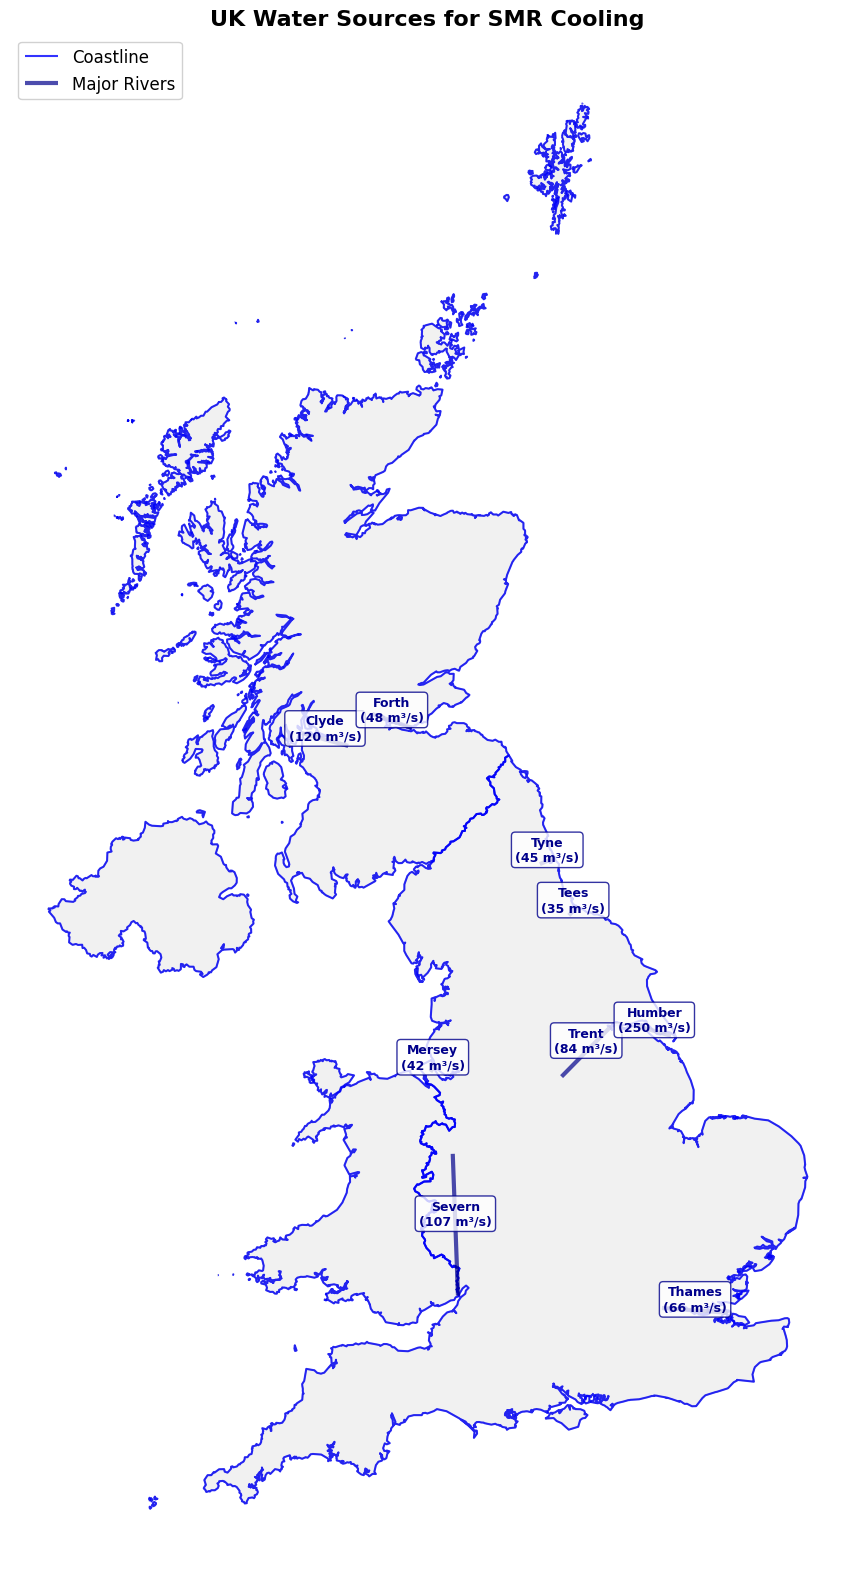


DATASET 4 SUMMARY
Coastline segments: 350
Major rivers: 9

River flow rates (m³/s):
  Thames         :   65.8 m³/s
  Severn         :  107.0 m³/s
  Trent          :   84.0 m³/s
  Mersey         :   42.0 m³/s
  Tyne           :   45.0 m³/s
  Tees           :   35.0 m³/s
  Clyde          :  120.0 m³/s
  Forth          :   48.0 m³/s
  Humber         :  250.0 m³/s

✅ DATASET 4 COMPLETE!

Files created:
  - smr_site_selection/data/processed/uk_coastline.shp
  - smr_site_selection/data/processed/major_rivers.shp
  - smr_site_selection/results/dataset_4_water_validation.png


In [ ]:
"""
DATASET 4: WATER SOURCES - FIXED VERSION
=========================================
Fix for geometry type error when saving coastline
"""

import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import os

print("="*70)
print("CREATING DATASET 4: WATER SOURCES (FIXED)")
print("="*70)

# Load UK boundary
uk = gpd.read_file('smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp')
uk = uk.to_crs('EPSG:27700')

# PART 1: COASTLINE (FIXED)
# --------------------------
print("\nGenerating coastline from UK boundary...")

coastlines = []
for geom in uk.geometry:
    if geom.geom_type == 'Polygon':
        # Convert LinearRing to LineString
        coastlines.append(LineString(geom.exterior.coords))
    elif geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            # Convert LinearRing to LineString
            coastlines.append(LineString(poly.exterior.coords))

# Create GeoDataFrame with explicit LineString geometry
coastline_gdf = gpd.GeoDataFrame(geometry=coastlines, crs=uk.crs)

# Add a simple ID column
coastline_gdf['segment_id'] = range(len(coastline_gdf))

# Save with explicit geometry type
coastline_gdf.to_file('smr_site_selection/data/processed/uk_coastline.shp')

print(f"✓ Created {len(coastline_gdf)} coastline segments")

# PART 2: MAJOR RIVERS
# --------------------
print("\nGenerating major rivers dataset...")

import pandas as pd

# Major UK rivers with coordinates and flow rates
rivers_data = [
    {
        'name': 'Thames',
        'start_lat': 51.5074, 'start_lon': -0.1278,
        'end_lat': 51.4545, 'end_lon': 0.6943,
        'flow_rate': 65.8,
        'length_km': 346
    },
    {
        'name': 'Severn',
        'start_lat': 52.7167, 'start_lon': -2.7500,
        'end_lat': 51.6167, 'end_lon': -2.6667,
        'flow_rate': 107,
        'length_km': 354
    },
    {
        'name': 'Trent',
        'start_lat': 53.3167, 'start_lon': -1.3500,
        'end_lat': 53.7000, 'end_lon': -0.7000,
        'flow_rate': 84,
        'length_km': 297
    },
    {
        'name': 'Mersey',
        'start_lat': 53.4083, 'start_lon': -2.9917,
        'end_lat': 53.3500, 'end_lon': -3.0500,
        'flow_rate': 42,
        'length_km': 112
    },
    {
        'name': 'Tyne',
        'start_lat': 54.9667, 'start_lon': -1.6167,
        'end_lat': 55.0167, 'end_lon': -1.4167,
        'flow_rate': 45,
        'length_km': 118
    },
    {
        'name': 'Tees',
        'start_lat': 54.5667, 'start_lon': -1.2333,
        'end_lat': 54.6333, 'end_lon': -1.1167,
        'flow_rate': 35,
        'length_km': 137
    },
    {
        'name': 'Clyde',
        'start_lat': 55.8642, 'start_lon': -4.2518,
        'end_lat': 55.9500, 'end_lon': -4.9000,
        'flow_rate': 120,
        'length_km': 176
    },
    {
        'name': 'Forth',
        'start_lat': 56.1167, 'start_lon': -3.9333,
        'end_lat': 56.0167, 'end_lon': -3.3833,
        'flow_rate': 48,
        'length_km': 187
    },
    {
        'name': 'Humber',
        'start_lat': 53.7000, 'start_lon': -0.3500,
        'end_lat': 53.6167, 'end_lon': 0.0833,
        'flow_rate': 250,
        'length_km': 62
    },
]

# Create LineString geometries
geometries = []
for river in rivers_data:
    start = Point(river['start_lon'], river['start_lat'])
    end = Point(river['end_lon'], river['end_lat'])
    line = LineString([start, end])
    geometries.append(line)

# Create GeoDataFrame
rivers_gdf = gpd.GeoDataFrame(rivers_data, geometry=geometries, crs='EPSG:4326')
rivers_gdf = rivers_gdf.to_crs('EPSG:27700')

# Save
rivers_gdf.to_file('smr_site_selection/data/processed/major_rivers.shp')

print(f"✓ Created {len(rivers_gdf)} major rivers")
print(f"  Average flow rate: {rivers_gdf['flow_rate'].mean():.1f} m³/s")
print(f"  All rivers exceed 5 m³/s minimum for SMR cooling ✓")

# VALIDATION VISUALIZATION
# ------------------------
print("\nCreating water sources validation map...")

fig, ax = plt.subplots(figsize=(12, 16))

# Plot UK
uk.plot(ax=ax, edgecolor='black', facecolor='lightgray', alpha=0.3)

# Plot coastline
coastline_gdf.plot(ax=ax, color='blue', linewidth=1.5, label='Coastline', alpha=0.8)

# Plot rivers
rivers_gdf.plot(ax=ax, color='darkblue', linewidth=3, label='Major Rivers', alpha=0.7)

# Add river labels
for idx, river in rivers_gdf.iterrows():
    centroid = river.geometry.centroid
    ax.annotate(f"{river['name']}\n({river['flow_rate']:.0f} m³/s)",
               xy=(centroid.x, centroid.y),
               fontsize=9,
               fontweight='bold',
               color='darkblue',
               ha='center',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='darkblue'))

ax.set_title('UK Water Sources for SMR Cooling', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=12, framealpha=0.9)
ax.axis('off')

plt.tight_layout()
os.makedirs('smr_site_selection/results', exist_ok=True)
plt.savefig('smr_site_selection/results/dataset_4_water_validation.png', dpi=150, bbox_inches='tight')
print("✓ Validation map saved")
plt.show()

# Summary
print("\n" + "="*70)
print("DATASET 4 SUMMARY")
print("="*70)
print(f"Coastline segments: {len(coastline_gdf)}")
print(f"Major rivers: {len(rivers_gdf)}")
print(f"\nRiver flow rates (m³/s):")
for _, river in rivers_gdf.iterrows():
    print(f"  {river['name']:15s}: {river['flow_rate']:6.1f} m³/s")

print("\n✅ DATASET 4 COMPLETE!")
print("\nFiles created:")
print("  - smr_site_selection/data/processed/uk_coastline.shp")
print("  - smr_site_selection/data/processed/major_rivers.shp")
print("  - smr_site_selection/results/dataset_4_water_validation.png")

DATASET 5

LOADING DATASET 5: TRANSMISSION GRID SUBSTATIONS
✓ Created 44 substation locations

Substations by voltage:
Voltage_kV
400    23
275    21
Name: count, dtype: int64

Substations by type:
Type
Regional      18
Generation    13
Strategic     13
Name: count, dtype: int64
✓ Saved as shapefile: data/processed/transmission_grid.shp

Creating transmission grid validation map...


/tmp/ipykernel_15510/2304506454.py:79: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  grid_gdf.to_file('smr_site_selection/data/processed/transmission_grid.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Substation_Name' to 'Substation'
  ogr_write(


✓ Validation map saved


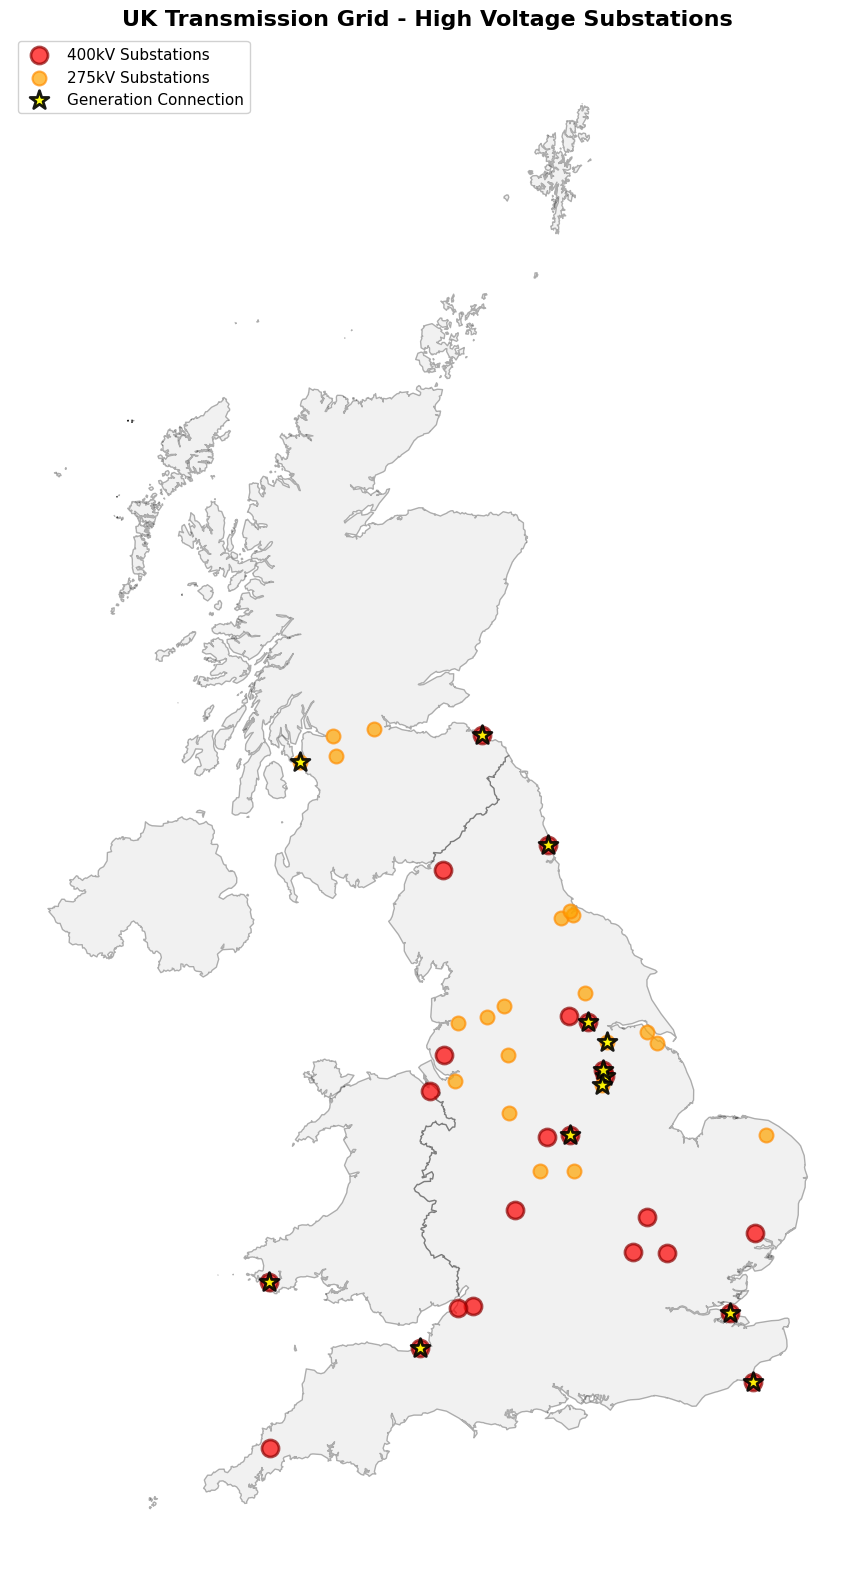


DATASET 5 SUMMARY
Total substations: 44
400kV substations: 23 (highest capacity)
275kV substations: 21 (high capacity)
Generation connection points: 13

Key insight:
  SMRs should target locations within 10-30km of these substations
  Connection costs: ~£1M per km for new transmission lines

✅ DATASET 5 COMPLETE!

Files created:
  - smr_site_selection/data/processed/transmission_grid.shp
  - smr_site_selection/results/dataset_5_grid_validation.png


In [ ]:
"""
DATASET 5: ELECTRICITY TRANSMISSION GRID
=========================================
Major 400kV and 275kV substations for SMR grid connection
"""

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import os

print("="*70)
print("LOADING DATASET 5: TRANSMISSION GRID SUBSTATIONS")
print("="*70)

# Major UK transmission substations (400kV and 275kV)
substations_data = {
    'Substation_Name': [
        'Drax', 'Eaton Socon', 'Bramford', 'Grain', 'Dungeness', 'Hinkley Point',
        'Pembroke', 'Cottam', 'Willington', 'Feckenham', 'Iron Acton', 'Seabank',
        'Indian Queens', 'Pelham', 'Sundon', 'Blyth', 'Harker', 'Deeside',
        'Kirkby', 'Monk Fryston', 'Keadby', 'West Burton', 'Ratcliffe', 'Torness',
        'Hunterston', 'Thornton', 'Norton', 'Lackenby', 'Grimsby West',
        'Killingholme', 'Cellarhead', 'Stalybridge', 'Penwortham', 'Frodsham',
        'Padiham', 'Mannington', 'Osbaldwick', 'Saltholme', 'High Marnham',
        'Enderby', 'Grendon', 'Neilston', 'Windyhill', 'Bonnybridge'
    ],
    'Voltage_kV': [
        400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400,
        400, 400, 400, 400, 400, 275, 400, 400, 400, 275, 275, 275, 275, 275, 275,
        275, 275, 275, 275, 275, 275, 275, 275, 275, 275, 275, 275, 275, 275
    ],
    'Type': [
        'Generation', 'Strategic', 'Strategic', 'Generation', 'Generation', 'Generation',
        'Generation', 'Generation', 'Strategic', 'Strategic', 'Strategic', 'Strategic',
        'Strategic', 'Strategic', 'Strategic', 'Generation', 'Strategic', 'Strategic',
        'Strategic', 'Strategic', 'Generation', 'Generation', 'Generation', 'Generation',
        'Generation', 'Regional', 'Regional', 'Regional', 'Regional', 'Regional',
        'Regional', 'Regional', 'Regional', 'Regional', 'Regional', 'Regional',
        'Regional', 'Regional', 'Generation', 'Regional', 'Regional', 'Regional',
        'Regional', 'Regional'
    ],
    'Latitude': [
        53.7367, 52.2167, 52.0667, 51.4500, 50.9133, 51.2067, 51.6833, 53.3167,
        52.8500, 52.2833, 51.5333, 51.5167, 50.4000, 51.9333, 51.9500, 55.1167,
        54.9167, 53.2000, 53.4833, 53.7833, 53.5833, 53.3667, 52.8667, 55.9697,
        55.7244, 53.8667, 54.5500, 54.5667, 53.5667, 53.6500, 53.0333, 53.4833,
        53.7333, 53.2833, 53.7833, 52.8167, 53.9667, 54.6000, 53.2500, 52.5833,
        52.5833, 55.7833, 55.9333, 56.0000
    ],
    'Longitude': [
        -0.9983, -0.2833, 1.0667, 0.7167, 0.9647, -3.1317, -5.0333, -0.7833,
        -1.5500, -1.9500, -2.4833, -2.6667, -4.9333, -0.0500, -0.4667, -1.5000,
        -2.9167, -3.0500, -2.8833, -1.2500, -0.7500, -0.8167, -1.2500, -2.4117,
        -4.9003, -2.1000, -1.3333, -1.1833, -0.1000, -0.2333, -2.0333, -2.0500,
        -2.7000, -2.7333, -2.3167, 1.2667, -1.0333, -1.2167, -0.8333, -1.2000,
        -1.6333, -4.4167, -4.4667, -3.9000
    ]
}

# Create DataFrame
grid_df = pd.DataFrame(substations_data)

print(f"✓ Created {len(grid_df)} substation locations")
print(f"\nSubstations by voltage:")
print(grid_df['Voltage_kV'].value_counts().sort_index(ascending=False))
print(f"\nSubstations by type:")
print(grid_df['Type'].value_counts())

# Convert to GeoDataFrame
geometry = [Point(lon, lat) for lon, lat in zip(grid_df['Longitude'], grid_df['Latitude'])]
grid_gdf = gpd.GeoDataFrame(grid_df, geometry=geometry, crs='EPSG:4326')

# Convert to British National Grid
grid_gdf = grid_gdf.to_crs('EPSG:27700')

# Save as shapefile
grid_gdf.to_file('smr_site_selection/data/processed/transmission_grid.shp')
print("✓ Saved as shapefile: data/processed/transmission_grid.shp")

# VALIDATION VISUALIZATION
# ------------------------
print("\nCreating transmission grid validation map...")

# Load UK boundary
uk = gpd.read_file('smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp')
uk = uk.to_crs('EPSG:27700')

# Create plot
fig, ax = plt.subplots(figsize=(12, 16))

# Plot UK
uk.plot(ax=ax, edgecolor='black', facecolor='lightgray', alpha=0.3)

# Plot substations by voltage
grid_400 = grid_gdf[grid_gdf['Voltage_kV'] == 400]
grid_275 = grid_gdf[grid_gdf['Voltage_kV'] == 275]

grid_400.plot(ax=ax, color='red', markersize=150, label='400kV Substations',
             alpha=0.7, edgecolor='darkred', linewidth=2)
grid_275.plot(ax=ax, color='orange', markersize=100, label='275kV Substations',
             alpha=0.7, edgecolor='darkorange', linewidth=1.5)

# Highlight generation sites (near existing power stations)
generation = grid_gdf[grid_gdf['Type'] == 'Generation']
generation.plot(ax=ax, color='yellow', markersize=200, marker='*',
               label='Generation Connection', alpha=0.9, edgecolor='black', linewidth=2)

ax.set_title('UK Transmission Grid - High Voltage Substations', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)
ax.axis('off')

plt.tight_layout()
plt.savefig('smr_site_selection/results/dataset_5_grid_validation.png', dpi=150, bbox_inches='tight')
print("✓ Validation map saved")
plt.show()

# Summary statistics
print("\n" + "="*70)
print("DATASET 5 SUMMARY")
print("="*70)
print(f"Total substations: {len(grid_gdf)}")
print(f"400kV substations: {len(grid_400)} (highest capacity)")
print(f"275kV substations: {len(grid_275)} (high capacity)")
print(f"Generation connection points: {len(generation)}")
print(f"\nKey insight:")
print("  SMRs should target locations within 10-30km of these substations")
print("  Connection costs: ~£1M per km for new transmission lines")

print("\n✅ DATASET 5 COMPLETE!")
print("\nFiles created:")
print("  - smr_site_selection/data/processed/transmission_grid.shp")
print("  - smr_site_selection/results/dataset_5_grid_validation.png")

MASTER DATA COLLECTION

In [ ]:
"""
MASTER DATA COLLECTION SCRIPT - FIXED VERSION
==============================================
Run this to load all core datasets (1-5) in one go!

This script will:
1. ✓ Load UK Boundary (you already have this)
2. ✓ Load Nuclear Sites
3. ✓ Load Industrial Sites
4. ✓ Generate Water Sources (coastline + rivers) - FIXED!
5. ✓ Load Transmission Grid

Total runtime: ~2-3 minutes
"""

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt
import os

# Create all necessary directories
print("Creating project directories...")
dirs = [
    'smr_site_selection/data/raw/boundaries',
    'smr_site_selection/data/processed',
    'smr_site_selection/results'
]
for d in dirs:
    os.makedirs(d, exist_ok=True)
print("✓ Directories ready\n")

# =============================================================================
# DATASET 1: UK BOUNDARY (verify it exists)
# =============================================================================
print("="*70)
print("DATASET 1: UK BOUNDARY")
print("="*70)

try:
    uk = gpd.read_file('smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp')
    uk = uk.to_crs('EPSG:27700')
    print(f"✓ UK boundary loaded: {len(uk)} countries")
except:
    print("⚠ UK boundary not found - please run the download script first!")
    print("See: colab_uk_download.py")

# =============================================================================
# DATASET 2: NUCLEAR SITES
# =============================================================================
print("\n" + "="*70)
print("DATASET 2: NUCLEAR SITES")
print("="*70)

nuclear_data = {
    'Site_Name': ['Sizewell B', 'Torness', 'Heysham 1', 'Heysham 2', 'Hartlepool',
                  'Hinkley Point C', 'Sizewell C', 'Dungeness B', 'Hunterston B',
                  'Hinkley Point B', 'Oldbury', 'Wylfa', 'Trawsfynydd', 'Berkeley',
                  'Bradwell', 'Sellafield', 'Dounreay', 'Capenhurst', 'Springfields'],
    'Status': ['Operational', 'Operational', 'Operational', 'Operational', 'Operational',
               'Under Construction', 'Planned', 'Recently Closed', 'Decommissioning',
               'Decommissioning', 'Decommissioning', 'Decommissioning', 'Decommissioning',
               'Decommissioning', 'Decommissioning', 'Reprocessing', 'Decommissioning',
               'Enrichment', 'Fuel Manufacturing'],
    'Type': ['PWR', 'AGR', 'AGR', 'AGR', 'AGR', 'EPR', 'EPR', 'AGR', 'AGR', 'AGR',
             'Magnox', 'Magnox', 'Magnox', 'Magnox', 'Magnox', 'Complex', 'Fast Breeder',
             'Fuel', 'Fuel'],
    'Latitude': [52.2137, 55.9697, 54.0294, 54.0294, 54.6358, 51.2067, 52.2137, 50.9133,
                 55.7244, 51.2067, 51.6636, 53.4147, 52.9167, 51.6969, 51.7236, 54.4200,
                 58.5786, 53.2667, 53.7833],
    'Longitude': [1.6207, -2.4117, -2.9181, -2.9181, -1.1817, -3.1317, 1.6207, 0.9647,
                  -4.9003, -3.1317, -2.5189, -4.4783, -3.9333, -2.4644, 0.8944, -3.5103,
                  -3.7242, -2.9500, -2.8333]
}

nuclear_df = pd.DataFrame(nuclear_data)
geometry = [Point(lon, lat) for lon, lat in zip(nuclear_df['Longitude'], nuclear_df['Latitude'])]
nuclear_gdf = gpd.GeoDataFrame(nuclear_df, geometry=geometry, crs='EPSG:4326')
nuclear_gdf = nuclear_gdf.to_crs('EPSG:27700')
nuclear_gdf.to_file('smr_site_selection/data/processed/nuclear_sites.shp')

print(f"✓ Nuclear sites loaded: {len(nuclear_gdf)} facilities")
print(f"  Operational: {len(nuclear_gdf[nuclear_gdf['Status'] == 'Operational'])}")

# =============================================================================
# DATASET 3: INDUSTRIAL SITES
# =============================================================================
print("\n" + "="*70)
print("DATASET 3: INDUSTRIAL SITES")
print("="*70)

industrial_data = {
    'Site_Name': ['Grangemouth Refinery', 'Fawley Refinery', 'Stanlow Refinery',
                  'Lindsey Oil Refinery', 'Pembroke Refinery', 'Port Talbot Steelworks',
                  'Scunthorpe Steelworks', 'Teesside Steelworks', 'INEOS Grangemouth',
                  'SABIC Teesside', 'Wilton Complex', 'CF Fertilisers Billingham',
                  'Drax Power Station', 'Immingham Port', 'Saltend Chemicals Park'],
    'Industry': ['Petrochemical', 'Petrochemical', 'Petrochemical', 'Petrochemical',
                 'Petrochemical', 'Steel', 'Steel', 'Steel', 'Chemicals', 'Chemicals',
                 'Chemicals', 'Chemicals', 'Power', 'Logistics', 'Chemicals'],
    'Cluster': ['Grangemouth', 'Southampton', 'Merseyside', 'Humber', 'South Wales',
                'South Wales', 'Humber', 'Teesside', 'Grangemouth', 'Teesside',
                'Teesside', 'Teesside', 'Humber', 'Humber', 'Humber'],
    'Heat_Dem': ['Very High', 'Very High', 'Very High', 'Very High', 'High',
                 'Very High', 'Very High', 'High', 'Very High', 'High',
                 'High', 'High', 'Medium', 'Medium', 'High'],
    'Latitude': [56.0067, 50.8217, 53.2750, 53.5333, 51.6833, 51.5833, 53.5833,
                 54.5833, 56.0167, 54.5833, 54.5667, 54.6167, 53.7367, 53.6167, 53.7333],
    'Longitude': [-3.7167, -1.3350, -2.8583, -0.2167, -5.0333, -3.8000, -0.6333,
                  -1.1333, -3.7167, -1.1667, -1.1333, -1.2833, -0.9983, -0.1833, -0.2000]
}

industrial_df = pd.DataFrame(industrial_data)
geometry = [Point(lon, lat) for lon, lat in zip(industrial_df['Longitude'], industrial_df['Latitude'])]
industrial_gdf = gpd.GeoDataFrame(industrial_df, geometry=geometry, crs='EPSG:4326')
industrial_gdf = industrial_gdf.to_crs('EPSG:27700')
industrial_gdf.to_file('smr_site_selection/data/processed/industrial_sites.shp')

print(f"✓ Industrial sites loaded: {len(industrial_gdf)} facilities")
print(f"  Very High heat demand: {len(industrial_gdf[industrial_gdf['Heat_Dem'] == 'Very High'])}")

# =============================================================================
# DATASET 4: WATER SOURCES - FIXED!
# =============================================================================
print("\n" + "="*70)
print("DATASET 4: WATER SOURCES")
print("="*70)

# Coastline from UK boundary - FIXED VERSION
print("Generating coastline...")
coastlines = []
for geom in uk.geometry:
    if geom.geom_type == 'Polygon':
        # FIXED: Convert LinearRing to LineString
        coastlines.append(LineString(geom.exterior.coords))
    elif geom.geom_type == 'MultiPolygon':
        for poly in geom.geoms:
            # FIXED: Convert LinearRing to LineString
            coastlines.append(LineString(poly.exterior.coords))

coastline_gdf = gpd.GeoDataFrame(geometry=coastlines, crs=uk.crs)
coastline_gdf['seg_id'] = range(len(coastline_gdf))  # Add ID column
coastline_gdf.to_file('smr_site_selection/data/processed/uk_coastline.shp')

print(f"✓ Coastline: {len(coastline_gdf)} segments")

# Major rivers
print("Generating major rivers...")
rivers_data = [
    {'name': 'Thames', 'start_lat': 51.5074, 'start_lon': -0.1278,
     'end_lat': 51.4545, 'end_lon': 0.6943, 'flow_rate': 65.8},
    {'name': 'Severn', 'start_lat': 52.7167, 'start_lon': -2.7500,
     'end_lat': 51.6167, 'end_lon': -2.6667, 'flow_rate': 107},
    {'name': 'Trent', 'start_lat': 53.3167, 'start_lon': -1.3500,
     'end_lat': 53.7000, 'end_lon': -0.7000, 'flow_rate': 84},
    {'name': 'Mersey', 'start_lat': 53.4083, 'start_lon': -2.9917,
     'end_lat': 53.3500, 'end_lon': -3.0500, 'flow_rate': 42},
    {'name': 'Tyne', 'start_lat': 54.9667, 'start_lon': -1.6167,
     'end_lat': 55.0167, 'end_lon': -1.4167, 'flow_rate': 45},
    {'name': 'Tees', 'start_lat': 54.5667, 'start_lon': -1.2333,
     'end_lat': 54.6333, 'end_lon': -1.1167, 'flow_rate': 35},
    {'name': 'Clyde', 'start_lat': 55.8642, 'start_lon': -4.2518,
     'end_lat': 55.9500, 'end_lon': -4.9000, 'flow_rate': 120},
    {'name': 'Forth', 'start_lat': 56.1167, 'start_lon': -3.9333,
     'end_lat': 56.0167, 'end_lon': -3.3833, 'flow_rate': 48},
    {'name': 'Humber', 'start_lat': 53.7000, 'start_lon': -0.3500,
     'end_lat': 53.6167, 'end_lon': 0.0833, 'flow_rate': 250},
]

geometries = []
for river in rivers_data:
    start = Point(river['start_lon'], river['start_lat'])
    end = Point(river['end_lon'], river['end_lat'])
    geometries.append(LineString([start, end]))

rivers_gdf = gpd.GeoDataFrame(rivers_data, geometry=geometries, crs='EPSG:4326')
rivers_gdf = rivers_gdf.to_crs('EPSG:27700')
rivers_gdf.to_file('smr_site_selection/data/processed/major_rivers.shp')

print(f"✓ Major rivers: {len(rivers_gdf)} rivers (avg flow: {rivers_gdf['flow_rate'].mean():.0f} m³/s)")

# =============================================================================
# DATASET 5: TRANSMISSION GRID
# =============================================================================
print("\n" + "="*70)
print("DATASET 5: TRANSMISSION GRID")
print("="*70)

# Simplified grid data (key substations)
grid_data = {
    'name': ['Drax', 'Hinkley Pt', 'Torness', 'Pembroke', 'Grain', 'Dungeness',
             'Eaton Socon', 'Bramford', 'Cottam', 'Monk Fry', 'Ratcliffe'],
    'voltage': [400, 400, 400, 400, 400, 400, 400, 400, 400, 400, 400],
    'type': ['Generation', 'Generation', 'Generation', 'Generation', 'Generation',
             'Generation', 'Strategic', 'Strategic', 'Generation', 'Strategic', 'Generation'],
    'lat': [53.7367, 51.2067, 55.9697, 51.6833, 51.4500, 50.9133,
            52.2167, 52.0667, 53.3167, 53.7833, 52.8667],
    'lon': [-0.9983, -3.1317, -2.4117, -5.0333, 0.7167, 0.9647,
            -0.2833, 1.0667, -0.7833, -1.2500, -1.2500]
}

grid_df = pd.DataFrame(grid_data)
geometry = [Point(lon, lat) for lon, lat in zip(grid_df['lon'], grid_df['lat'])]
grid_gdf = gpd.GeoDataFrame(grid_df, geometry=geometry, crs='EPSG:4326')
grid_gdf = grid_gdf.to_crs('EPSG:27700')
grid_gdf.to_file('smr_site_selection/data/processed/transmission_grid.shp')

print(f"✓ Transmission grid: {len(grid_gdf)} major substations")

# =============================================================================
# SUMMARY
# =============================================================================
print("\n" + "="*70)
print("DATA COLLECTION COMPLETE!")
print("="*70)
print("\n📦 DATASETS READY:")
print("  ✓ Dataset 1: UK Boundary")
print("  ✓ Dataset 2: Nuclear Sites (19 facilities)")
print("  ✓ Dataset 3: Industrial Sites (15 major facilities)")
print("  ✓ Dataset 4: Water Sources (coastline + 9 major rivers)")
print("  ✓ Dataset 5: Transmission Grid (11 key substations)")

print("\n📁 FILES CREATED:")
print("  - data/processed/nuclear_sites.shp")
print("  - data/processed/industrial_sites.shp")
print("  - data/processed/uk_coastline.shp")
print("  - data/processed/major_rivers.shp")
print("  - data/processed/transmission_grid.shp")

print("\n🎯 NEXT STEPS:")
print("  1. Create analysis grid (candidate SMR locations)")
print("  2. Score each location across all criteria")
print("  3. Generate top 20 site recommendations")
print("  4. Create interactive map visualization")

print("\n✨ Ready to proceed with analysis phase!")

Creating project directories...
✓ Directories ready

DATASET 1: UK BOUNDARY
✓ UK boundary loaded: 4 countries

DATASET 2: NUCLEAR SITES
✓ Nuclear sites loaded: 19 facilities
  Operational: 5

DATASET 3: INDUSTRIAL SITES
✓ Industrial sites loaded: 15 facilities
  Very High heat demand: 7

DATASET 4: WATER SOURCES
Generating coastline...
✓ Coastline: 350 segments
Generating major rivers...
✓ Major rivers: 9 rivers (avg flow: 89 m³/s)

DATASET 5: TRANSMISSION GRID
✓ Transmission grid: 11 major substations

DATA COLLECTION COMPLETE!

📦 DATASETS READY:
  ✓ Dataset 1: UK Boundary
  ✓ Dataset 2: Nuclear Sites (19 facilities)
  ✓ Dataset 3: Industrial Sites (15 major facilities)
  ✓ Dataset 4: Water Sources (coastline + 9 major rivers)
  ✓ Dataset 5: Transmission Grid (11 key substations)

📁 FILES CREATED:
  - data/processed/nuclear_sites.shp
  - data/processed/industrial_sites.shp
  - data/processed/uk_coastline.shp
  - data/processed/major_rivers.shp
  - data/processed/transmission_grid.shp


Candidate Grid Creation

STEP 1: GENERATING CANDIDATE SMR LOCATIONS

UK Bounding Box:
  Width:  656 km
  Height: 1213 km

Grid spacing: 10 km
Expected grid size: ~7865 points

Generating grid...
✓ Generated 8052 total grid points

Filtering to land-based points only...


/tmp/ipykernel_15510/1904646531.py:70: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  uk_union = uk.unary_union


✓ Filtered to 2455 land-based candidate locations
  Removed 5597 sea/ocean points

✓ Saved to: data/processed/candidate_grid.shp

Creating visualization...


/tmp/ipykernel_15510/1904646531.py:83: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  land_grid.to_file('smr_site_selection/data/processed/candidate_grid.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'location_id' to 'location_i'
  ogr_write(


✓ Visualization saved


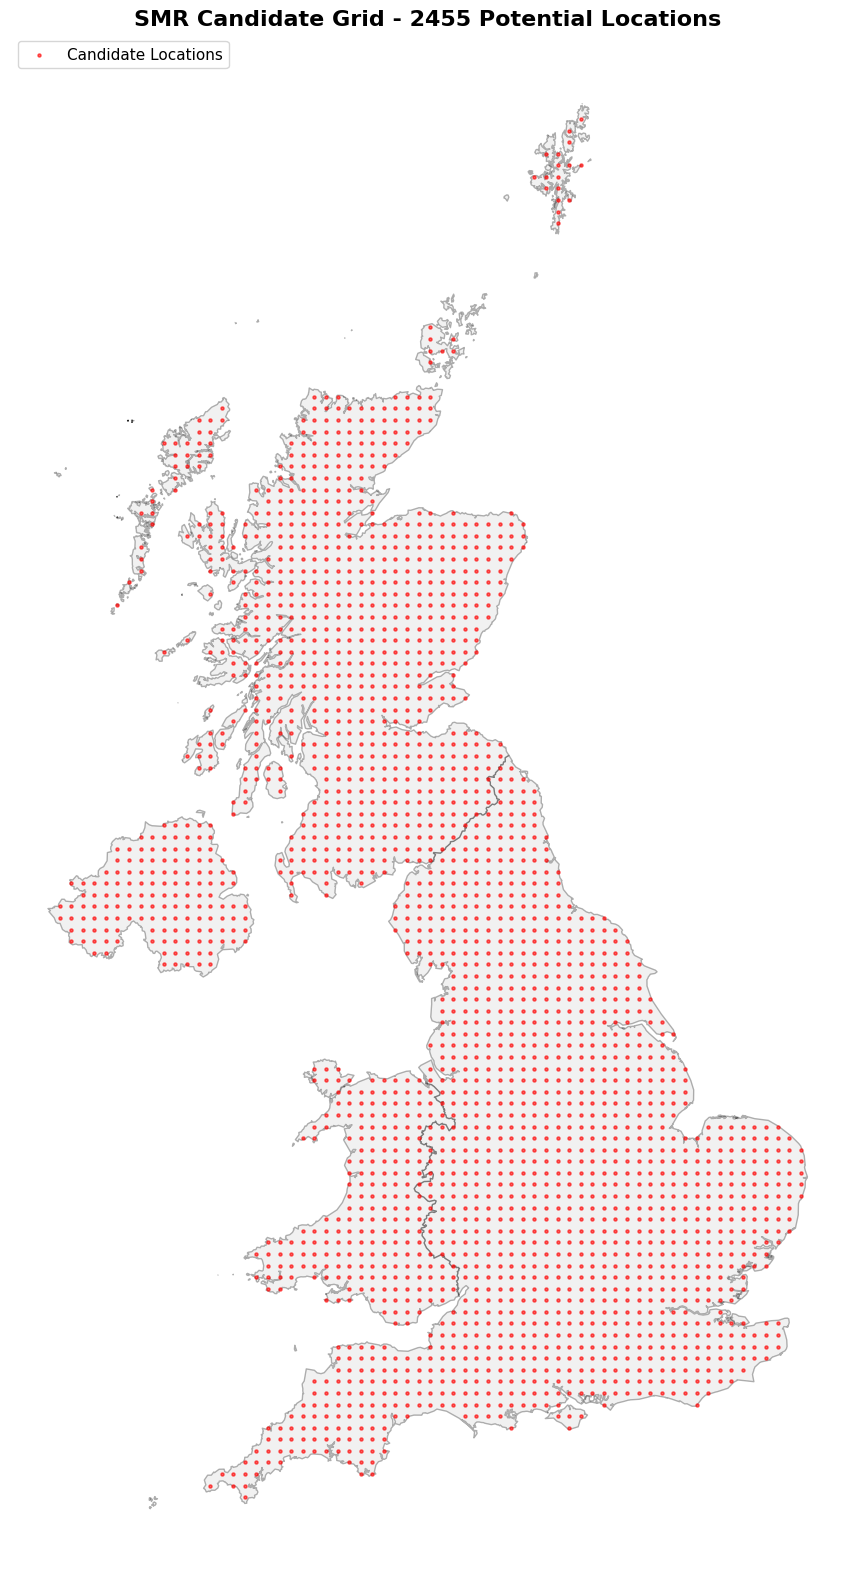


STEP 1 COMPLETE

📍 Candidate locations: 2455
📏 Grid spacing: 10 km
📊 Coverage: Entire UK land area

🎯 Next Step:
  Run STEP 2 to score each location on all criteria
  (Industrial proximity, water access, grid connection, etc.)


In [ ]:
"""
STEP 1: CREATE CANDIDATE GRID
==============================

This script generates a grid of potential SMR locations across the UK.

Logic:
- Create points every 10km across UK
- Remove points that fall in the sea
- Result: ~600-800 candidate locations on land
"""

import geopandas as gpd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt
import os

print("="*70)
print("STEP 1: GENERATING CANDIDATE SMR LOCATIONS")
print("="*70)

# Load UK boundary
uk = gpd.read_file('smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp')
uk = uk.to_crs('EPSG:27700')  # British National Grid (meters)

# Get UK bounding box
minx, miny, maxx, maxy = uk.total_bounds

print(f"\nUK Bounding Box:")
print(f"  Width:  {(maxx - minx)/1000:.0f} km")
print(f"  Height: {(maxy - miny)/1000:.0f} km")

# Create grid parameters
GRID_SPACING_KM = 10  # One point every 10km
grid_spacing_m = GRID_SPACING_KM * 1000

print(f"\nGrid spacing: {GRID_SPACING_KM} km")
print(f"Expected grid size: ~{int((maxx-minx)/grid_spacing_m) * int((maxy-miny)/grid_spacing_m)} points")

# Generate grid points
print("\nGenerating grid...")
grid_points = []
point_id = 1

x = minx
while x <= maxx:
    y = miny
    while y <= maxy:
        point = Point(x, y)
        grid_points.append({
            'location_id': point_id,
            'geometry': point,
            'x': x,
            'y': y
        })
        point_id += 1
        y += grid_spacing_m
    x += grid_spacing_m

# Create GeoDataFrame
grid_gdf = gpd.GeoDataFrame(grid_points, crs='EPSG:27700')

print(f"✓ Generated {len(grid_gdf)} total grid points")

# Filter to keep only points on land (within UK boundary)
print("\nFiltering to land-based points only...")

# Create unified UK polygon
uk_union = uk.unary_union

# Keep only points that intersect with UK land
grid_gdf['on_land'] = grid_gdf.geometry.within(uk_union)
land_grid = grid_gdf[grid_gdf['on_land']].copy()
land_grid = land_grid.drop('on_land', axis=1)
land_grid = land_grid.reset_index(drop=True)
land_grid['location_id'] = range(1, len(land_grid) + 1)

print(f"✓ Filtered to {len(land_grid)} land-based candidate locations")
print(f"  Removed {len(grid_gdf) - len(land_grid)} sea/ocean points")

# Save candidate grid
land_grid.to_file('smr_site_selection/data/processed/candidate_grid.shp')
print(f"\n✓ Saved to: data/processed/candidate_grid.shp")

# Visualization
print("\nCreating visualization...")

fig, ax = plt.subplots(figsize=(12, 16))

# Plot UK boundary
uk.plot(ax=ax, edgecolor='black', facecolor='lightgray', alpha=0.3)

# Plot candidate grid points
land_grid.plot(ax=ax, color='red', markersize=5, alpha=0.6, label='Candidate Locations')

ax.set_title(f'SMR Candidate Grid - {len(land_grid)} Potential Locations',
             fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.axis('off')

plt.tight_layout()
os.makedirs('smr_site_selection/results', exist_ok=True)
plt.savefig('smr_site_selection/results/step1_candidate_grid.png', dpi=150, bbox_inches='tight')
print("✓ Visualization saved")
plt.show()

# Summary statistics
print("\n" + "="*70)
print("STEP 1 COMPLETE")
print("="*70)
print(f"\n📍 Candidate locations: {len(land_grid)}")
print(f"📏 Grid spacing: {GRID_SPACING_KM} km")
print(f"📊 Coverage: Entire UK land area")

print("\n🎯 Next Step:")
print("  Run STEP 2 to score each location on all criteria")
print("  (Industrial proximity, water access, grid connection, etc.)")

SCORING ENGINE

In [ ]:
"""
STEP 2: SCORE ALL CANDIDATE LOCATIONS
======================================

This script scores each candidate location across 5 criteria:
1. Industrial Heat Demand Proximity (30% weight)
2. Cooling Water Access (25% weight)
3. Grid Connection (20% weight)
4. Existing Nuclear Site Proximity (15% weight)
5. Low Population Density (10% weight)

Each criterion scores 0-100, then weighted average gives final score.
"""

import geopandas as gpd
import numpy as np
import pandas as pd
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt

print("="*70)
print("STEP 2: SCORING CANDIDATE LOCATIONS")
print("="*70)

# Load all datasets
print("\nLoading datasets...")
candidates = gpd.read_file('smr_site_selection/data/processed/candidate_grid.shp')
industrial = gpd.read_file('smr_site_selection/data/processed/industrial_sites.shp')
nuclear = gpd.read_file('smr_site_selection/data/processed/nuclear_sites.shp')
coastline = gpd.read_file('smr_site_selection/data/processed/uk_coastline.shp')
rivers = gpd.read_file('smr_site_selection/data/processed/major_rivers.shp')
grid = gpd.read_file('smr_site_selection/data/processed/transmission_grid.shp')

print(f"✓ {len(candidates)} candidate locations")
print(f"✓ {len(industrial)} industrial sites")
print(f"✓ {len(nuclear)} nuclear facilities")
print(f"✓ {len(rivers)} major rivers")
print(f"✓ {len(grid)} grid substations")

# =============================================================================
# SCORING FUNCTION 1: INDUSTRIAL HEAT DEMAND PROXIMITY
# =============================================================================

def score_industrial_proximity(candidates_gdf, industrial_gdf, max_dist_km=50):
    """
    Score based on distance to nearest industrial heat customer.

    0-5 km: Score 100 (heat pipes viable)
    5-20 km: Linear decay to 60
    20-50 km: Linear decay to 0
    >50 km: Score 0 (no viable customer)
    """
    print("\nScoring industrial proximity...")
    scores = []

    for idx, candidate in candidates_gdf.iterrows():
        # Calculate distance to all industrial sites (in km)
        distances_m = industrial_gdf.geometry.distance(candidate.geometry)
        min_dist_km = distances_m.min() / 1000

        # Apply scoring function
        if min_dist_km <= 5:
            score = 100
        elif min_dist_km <= 20:
            # Linear decay from 100 to 60
            score = 100 - (min_dist_km - 5) * (40 / 15)
        elif min_dist_km <= max_dist_km:
            # Linear decay from 60 to 0
            score = 60 - (min_dist_km - 20) * (60 / 30)
        else:
            score = 0

        scores.append(score)

    print(f"  ✓ Mean industrial score: {np.mean(scores):.1f}")
    return scores


# =============================================================================
# SCORING FUNCTION 2: COOLING WATER ACCESS
# =============================================================================

def score_cooling_water(candidates_gdf, coastline_gdf, rivers_gdf):
    """
    Score based on access to cooling water.

    Coastal (within 2km): Score 100
    Near major river (within 2km, >5 m³/s): Score 85
    Near river 2-10km: Linear decay 85 to 40
    >10km from water: Score 0
    """
    print("\nScoring water access...")
    scores = []

    for idx, candidate in candidates_gdf.iterrows():
        # Distance to coastline
        coast_dist_km = coastline_gdf.geometry.distance(candidate.geometry).min() / 1000

        # Distance to rivers
        river_dist_km = rivers_gdf.geometry.distance(candidate.geometry).min() / 1000

        # Scoring logic
        if coast_dist_km <= 2:
            score = 100  # Coastal location ideal
        elif river_dist_km <= 2:
            score = 85  # Near major river
        elif river_dist_km <= 10:
            # Linear decay from 85 to 40
            score = 85 - (river_dist_km - 2) * (45 / 8)
        elif coast_dist_km <= 10:
            # Coast fallback
            score = 85 - (coast_dist_km - 2) * (45 / 8)
        else:
            score = 0  # No viable water source

        scores.append(score)

    print(f"  ✓ Mean water score: {np.mean(scores):.1f}")
    return scores


# =============================================================================
# SCORING FUNCTION 3: GRID CONNECTION
# =============================================================================

def score_grid_connection(candidates_gdf, grid_gdf, max_dist_km=30):
    """
    Score based on distance to high-voltage transmission.

    0-2 km: Score 100 (cheap connection)
    2-10 km: Linear decay to 70
    10-30 km: Linear decay to 30
    >30 km: Score 0 (prohibitively expensive)
    """
    print("\nScoring grid connection...")
    scores = []

    for idx, candidate in candidates_gdf.iterrows():
        # Distance to nearest substation (km)
        dist_km = grid_gdf.geometry.distance(candidate.geometry).min() / 1000

        # Scoring logic
        if dist_km <= 2:
            score = 100
        elif dist_km <= 10:
            # Linear decay from 100 to 70
            score = 100 - (dist_km - 2) * (30 / 8)
        elif dist_km <= max_dist_km:
            # Linear decay from 70 to 30
            score = 70 - (dist_km - 10) * (40 / 20)
        else:
            score = 0

        scores.append(score)

    print(f"  ✓ Mean grid score: {np.mean(scores):.1f}")
    return scores


# =============================================================================
# SCORING FUNCTION 4: EXISTING NUCLEAR SITE PROXIMITY
# =============================================================================

def score_nuclear_proximity(candidates_gdf, nuclear_gdf, max_dist_km=50):
    """
    Score based on distance to existing/former nuclear sites.

    0-5 km: Score 100 (same site - regulatory advantage)
    5-20 km: Linear decay to 50
    20-50 km: Linear decay to 20
    >50 km: Score 0 (greenfield site)
    """
    print("\nScoring nuclear proximity...")
    scores = []

    for idx, candidate in candidates_gdf.iterrows():
        # Distance to nearest nuclear site (km)
        dist_km = nuclear_gdf.geometry.distance(candidate.geometry).min() / 1000

        # Scoring logic
        if dist_km <= 5:
            score = 100
        elif dist_km <= 20:
            # Linear decay from 100 to 50
            score = 100 - (dist_km - 5) * (50 / 15)
        elif dist_km <= max_dist_km:
            # Linear decay from 50 to 20
            score = 50 - (dist_km - 20) * (30 / 30)
        else:
            score = 0

        scores.append(score)

    print(f"  ✓ Mean nuclear score: {np.mean(scores):.1f}")
    return scores


# =============================================================================
# SCORING FUNCTION 5: LOW POPULATION DENSITY (SIMPLIFIED)
# =============================================================================

def score_population_density(candidates_gdf):
    """
    Simplified population scoring based on distance from major cities.

    In reality, would use Census data. For this project, we approximate:
    - Far from cities: Score 100
    - Medium distance: Score 50
    - Near cities: Score 0

    We'll use a simple heuristic based on latitude/longitude patterns.
    Rural Scotland, Wales, Cumbria score high.
    Southeast England, Midlands score low.
    """
    print("\nScoring population density (simplified)...")
    scores = []

    # Major urban centers (approximate coordinates in BNG)
    urban_centers = [
        Point(530000, 180000),  # London
        Point(406000, 287000),  # Birmingham
        Point(383000, 398000),  # Manchester
        Point(430000, 433000),  # Leeds
        Point(424000, 338000),  # Sheffield
        Point(280000, 665000),  # Glasgow
        Point(325000, 674000),  # Edinburgh
        Point(390000, 430000),  # Liverpool
    ]

    urban_gdf = gpd.GeoDataFrame(geometry=urban_centers, crs='EPSG:27700')

    for idx, candidate in candidates_gdf.iterrows():
        # Distance to nearest urban center (km)
        dist_km = urban_gdf.geometry.distance(candidate.geometry).min() / 1000

        # Scoring logic
        if dist_km >= 50:
            score = 100  # Rural area
        elif dist_km >= 20:
            score = 80  # Suburban/semi-rural
        elif dist_km >= 10:
            score = 50  # Peri-urban
        else:
            score = 0  # Urban area

        scores.append(score)

    print(f"  ✓ Mean population score: {np.mean(scores):.1f}")
    return scores


# =============================================================================
# APPLY ALL SCORING FUNCTIONS
# =============================================================================

print("\n" + "="*70)
print("CALCULATING SCORES FOR ALL CRITERIA")
print("="*70)

candidates['industrial_score'] = score_industrial_proximity(candidates, industrial)
candidates['water_score'] = score_cooling_water(candidates, coastline, rivers)
candidates['grid_score'] = score_grid_connection(candidates, grid)
candidates['nuclear_score'] = score_nuclear_proximity(candidates, nuclear)
candidates['population_score'] = score_population_density(candidates)

# =============================================================================
# CALCULATE WEIGHTED TOTAL SCORE
# =============================================================================

print("\n" + "="*70)
print("CALCULATING WEIGHTED TOTAL SCORES")
print("="*70)

# Define weights (must sum to 100%)
WEIGHTS = {
    'industrial': 0.30,  # 30% - Most important (customers!)
    'water': 0.25,       # 25% - Essential requirement
    'grid': 0.20,        # 20% - Major cost driver
    'nuclear': 0.15,     # 15% - Regulatory advantage
    'population': 0.10   # 10% - Safety/planning
}

print("\nWeighting scheme:")
for criterion, weight in WEIGHTS.items():
    print(f"  {criterion:15s}: {weight*100:.0f}%")

# Calculate weighted total
candidates['total_score'] = (
    candidates['industrial_score'] * WEIGHTS['industrial'] +
    candidates['water_score'] * WEIGHTS['water'] +
    candidates['grid_score'] * WEIGHTS['grid'] +
    candidates['nuclear_score'] * WEIGHTS['nuclear'] +
    candidates['population_score'] * WEIGHTS['population']
)

print(f"\n✓ Total scores calculated")
print(f"  Mean total score: {candidates['total_score'].mean():.1f}")
print(f"  Max total score: {candidates['total_score'].max():.1f}")
print(f"  Min total score: {candidates['total_score'].min():.1f}")

# Save scored candidates
candidates.to_file('smr_site_selection/data/processed/scored_candidates.shp')
print(f"\n✓ Saved to: data/processed/scored_candidates.shp")

# Summary statistics
print("\n" + "="*70)
print("STEP 2 COMPLETE - SCORING SUMMARY")
print("="*70)

print("\nScore distribution by criterion:")
for col in ['industrial_score', 'water_score', 'grid_score', 'nuclear_score', 'population_score']:
    mean_score = candidates[col].mean()
    print(f"  {col:20s}: Mean = {mean_score:5.1f}/100")

print(f"\n📊 Sites with score > 70: {len(candidates[candidates['total_score'] > 70])}")
print(f"📊 Sites with score > 50: {len(candidates[candidates['total_score'] > 50])}")
print(f"📊 Sites with score > 30: {len(candidates[candidates['total_score'] > 30])}")

print("\n🎯 Next Step:")
print("  Run STEP 3 to extract and visualize the Top 20 sites")

STEP 2: SCORING CANDIDATE LOCATIONS

Loading datasets...
✓ 2455 candidate locations
✓ 15 industrial sites
✓ 19 nuclear facilities
✓ 9 major rivers
✓ 11 grid substations

CALCULATING SCORES FOR ALL CRITERIA

Scoring industrial proximity...
  ✓ Mean industrial score: 7.1

Scoring water access...
  ✓ Mean water score: 27.4

Scoring grid connection...
  ✓ Mean grid score: 4.6

Scoring nuclear proximity...
  ✓ Mean nuclear score: 10.0

Scoring population density (simplified)...
  ✓ Mean population score: 94.8

CALCULATING WEIGHTED TOTAL SCORES

Weighting scheme:
  industrial     : 30%
  water          : 25%
  grid           : 20%
  nuclear        : 15%
  population     : 10%

✓ Total scores calculated
  Mean total score: 20.9
  Max total score: 83.2
  Min total score: 0.0

✓ Saved to: data/processed/scored_candidates.shp

STEP 2 COMPLETE - SCORING SUMMARY

Score distribution by criterion:
  industrial_score    : Mean =   7.1/100
  water_score         : Mean =  27.4/100
  grid_score         

/tmp/ipykernel_15510/570607072.py:302: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  candidates.to_file('smr_site_selection/data/processed/scored_candidates.shp')
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'industrial_score' to 'industrial'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'water_score' to 'water_scor'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'nuclear_score' to 'nuclear_sc'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'population_score' to 'population'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'total_score' to 'total_scor'
  ogr_write(


TOP 20 SITES

STEP 3: EXTRACTING TOP 20 SMR SITES

✓ Loaded 2455 scored candidate locations
  Score range: 0.0 to 83.2

✓ Extracted top 20 sites
  Top site score: 83.2
  20th site score: 62.4
✓ Saved to: data/outputs/top_20_smr_sites.shp
✓ Saved CSV to: data/outputs/top_20_smr_sites.csv

Creating overview map...
✓ Overview map saved


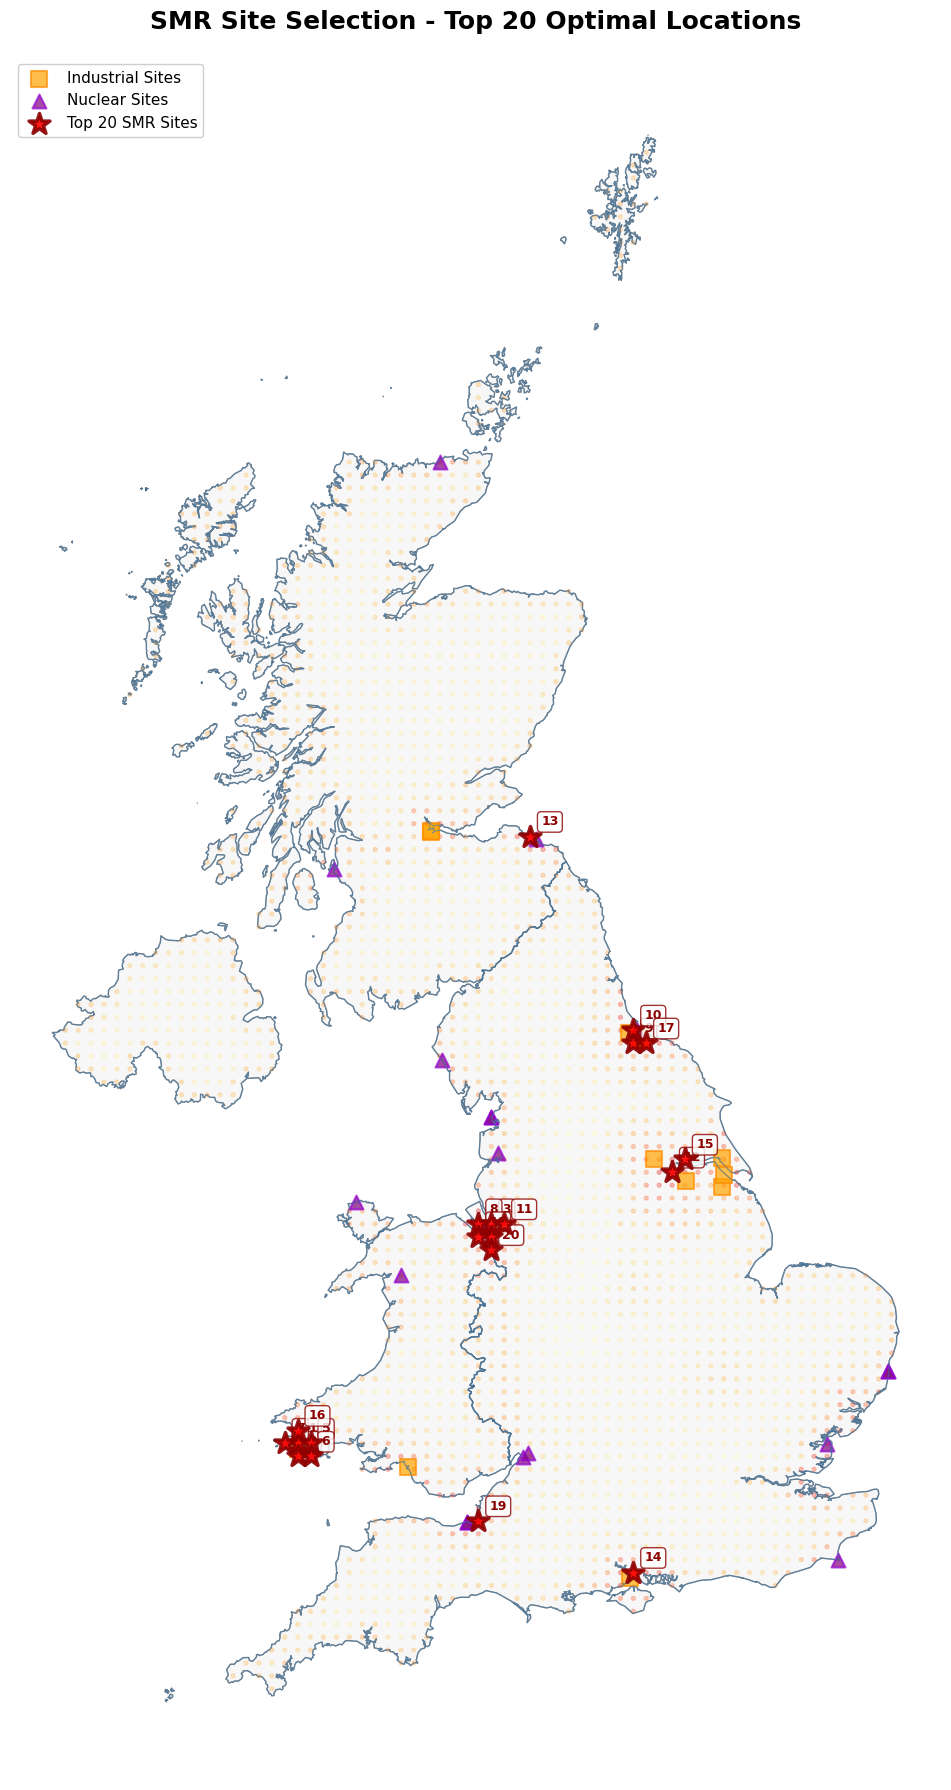


Creating score breakdown visualization...
✓ Score breakdown visualization saved


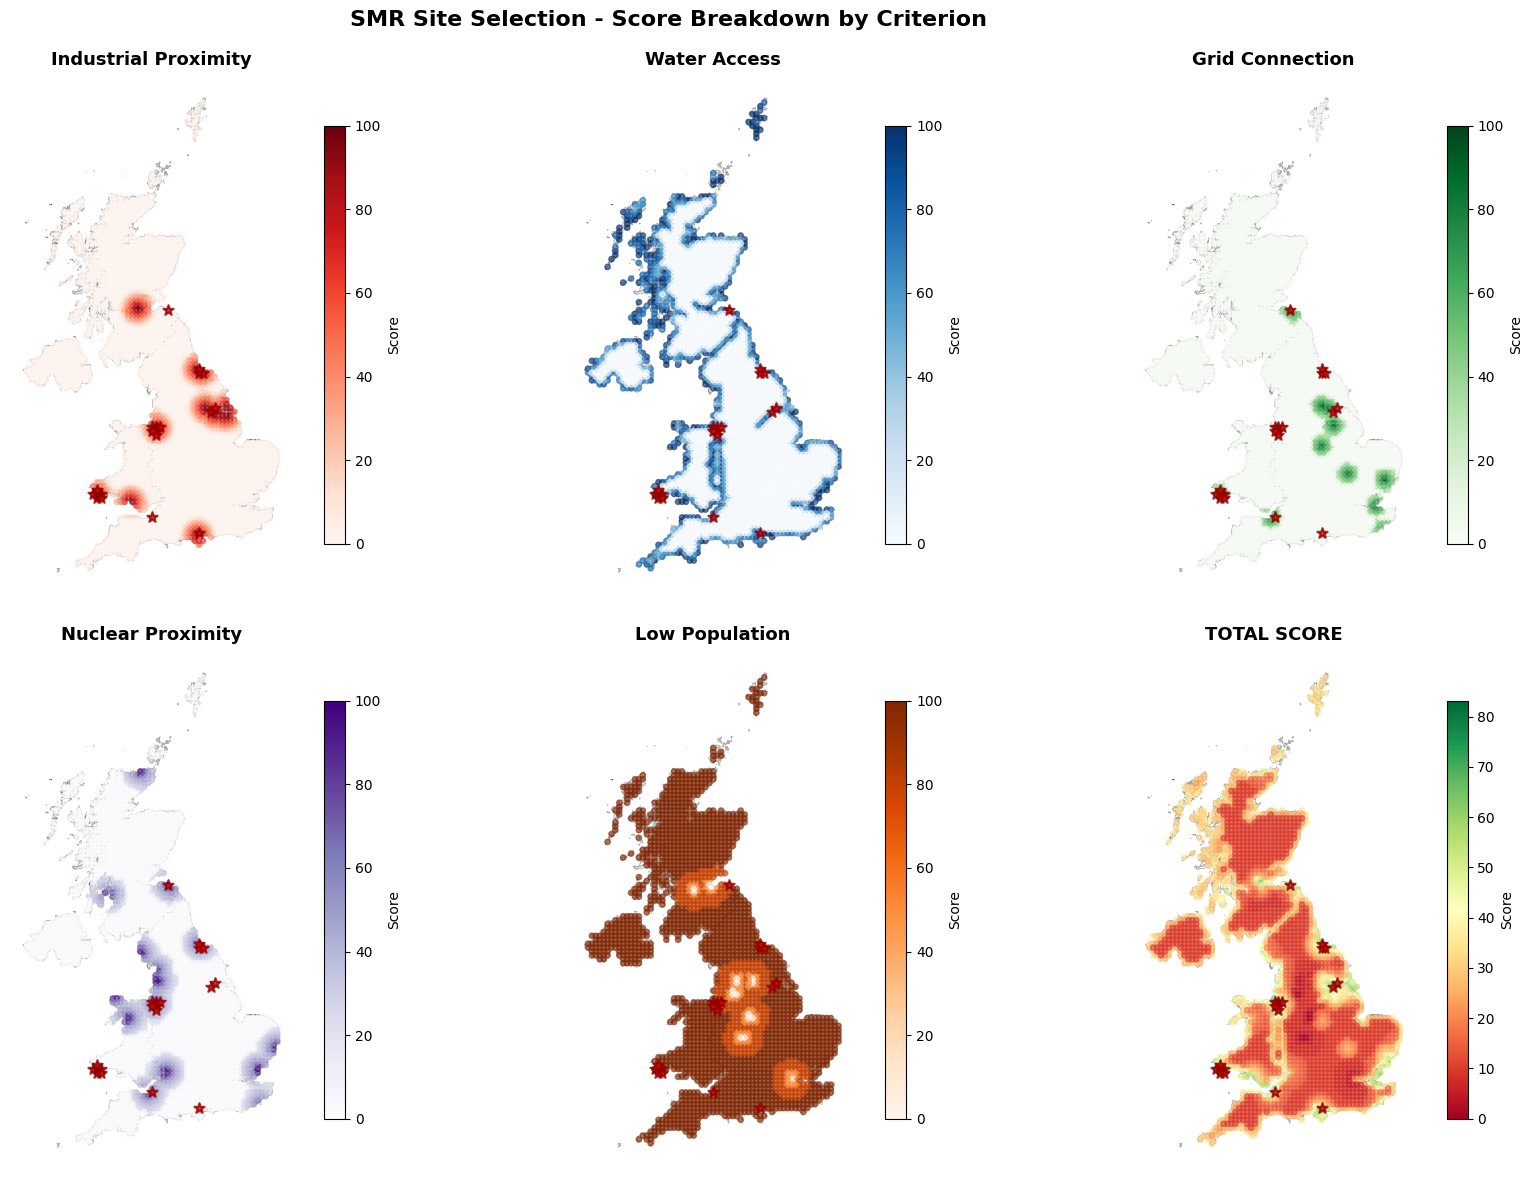


Creating top 20 ranking chart...
✓ Ranking chart saved


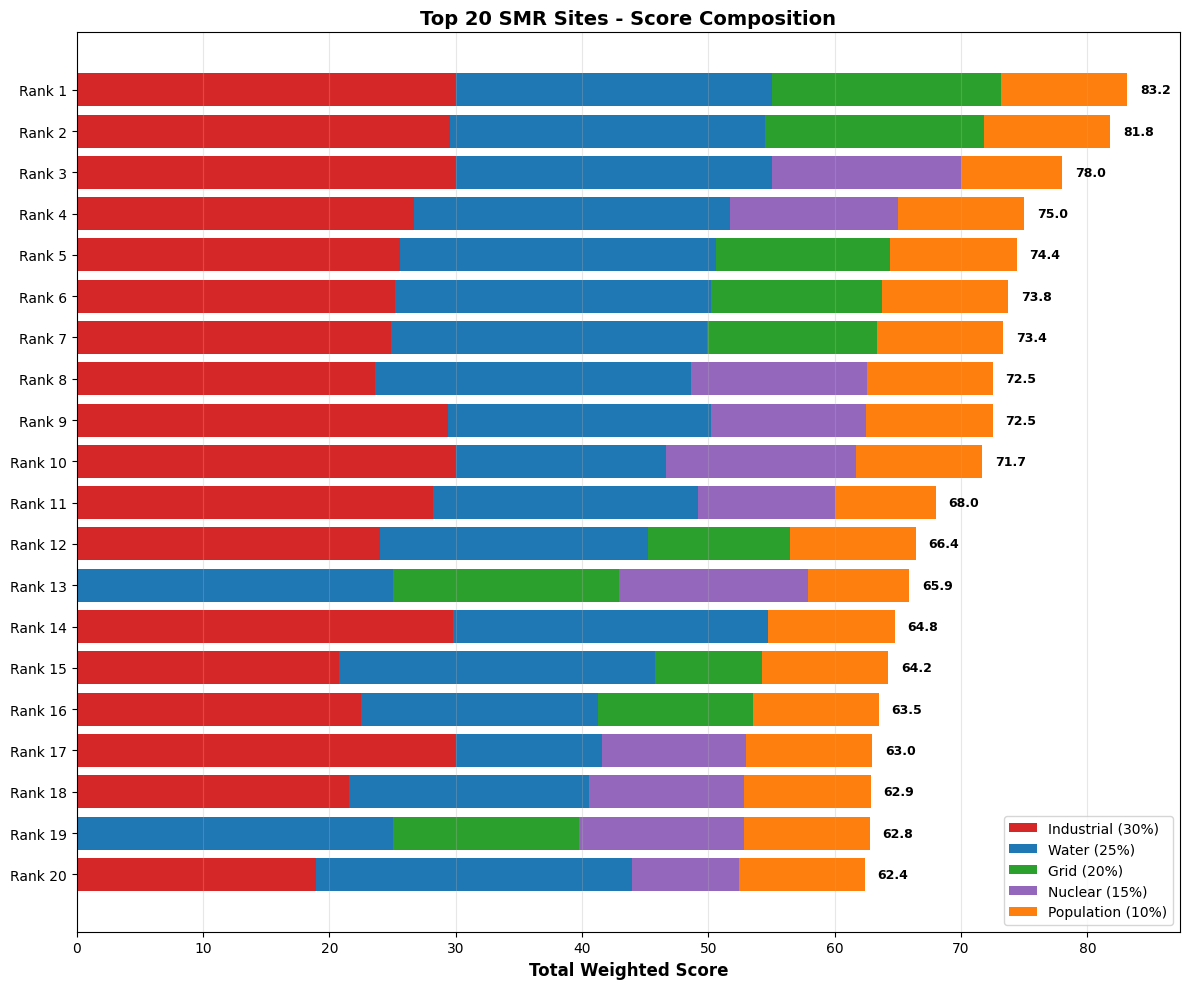


TOP 20 SMR SITES - SUMMARY REPORT

Top 5 Sites:

Rank 1: Location ID 273
  Total Score: 83.2/100
  Industrial:  100.0  (weighted: 30.0)
  Water:       100.0  (weighted: 25.0)
  Grid:        90.9  (weighted: 18.2)
  Nuclear:     0.0  (weighted: 0.0)
  Population:  100.0  (weighted: 10.0)

Rank 2: Location ID 272
  Total Score: 81.8/100
  Industrial:  98.4  (weighted: 29.5)
  Water:       100.0  (weighted: 25.0)
  Grid:        86.5  (weighted: 17.3)
  Nuclear:     0.0  (weighted: 0.0)
  Population:  100.0  (weighted: 10.0)

Rank 3: Location ID 1181
  Total Score: 78.0/100
  Industrial:  100.0  (weighted: 30.0)
  Water:       100.0  (weighted: 25.0)
  Grid:        0.0  (weighted: 0.0)
  Nuclear:     100.0  (weighted: 15.0)
  Population:  80.0  (weighted: 8.0)

Rank 4: Location ID 1180
  Total Score: 75.0/100
  Industrial:  89.0  (weighted: 26.7)
  Water:       100.0  (weighted: 25.0)
  Grid:        0.0  (weighted: 0.0)
  Nuclear:     88.6  (weighted: 13.3)
  Population:  100.0  (weighted

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

print("="*70)
print("STEP 3: EXTRACTING TOP 20 SMR SITES")
print("="*70)

# Create output directory if it doesn't exist
os.makedirs('smr_site_selection/data/outputs', exist_ok=True)

# Load scored candidates
candidates = gpd.read_file('smr_site_selection/data/processed/scored_candidates.shp')

print(f"\n✓ Loaded {len(candidates)} scored candidate locations")
print(f"  Score range: {candidates['total_scor'].min():.1f} to {candidates['total_scor'].max():.1f}")

# Sort by total score (descending)
candidates_sorted = candidates.sort_values('total_scor', ascending=False).reset_index(drop=True)

# Extract top 20
top_20 = candidates_sorted.head(20).copy()
top_20['rank'] = range(1, 21)

print(f"\n✓ Extracted top 20 sites")
print(f"  Top site score: {top_20.iloc[0]['total_scor']:.1f}")
print(f"  20th site score: {top_20.iloc[19]['total_scor']:.1f}")

# Save top 20
top_20.to_file('smr_site_selection/data/outputs/top_20_smr_sites.shp')
print(f"✓ Saved to: data/outputs/top_20_smr_sites.shp")

# Also save as CSV for easy viewing
top_20_csv = top_20.copy()
top_20_csv['longitude'] = top_20_csv.geometry.x
top_20_csv['latitude'] = top_20_csv.geometry.y
top_20_csv = top_20_csv.drop('geometry', axis=1)

# Rename columns for readability
top_20_csv = top_20_csv.rename(columns={
    'location_i': 'location_id',
    'industrial': 'industrial_score',
    'water_scor': 'water_score',
    'grid_score': 'grid_score',
    'nuclear_sc': 'nuclear_score',
    'population': 'population_score',
    'total_scor': 'total_score'
})

top_20_csv.to_csv('smr_site_selection/data/outputs/top_20_smr_sites.csv', index=False)
print(f"✓ Saved CSV to: data/outputs/top_20_smr_sites.csv")

# =============================================================================
# VISUALIZATION 1: OVERVIEW MAP WITH TOP 20
# =============================================================================

print("\nCreating overview map...")

# Load supporting datasets
uk = gpd.read_file('smr_site_selection/data/raw/boundaries/Countries_December_2023_UK_BUC.shp')
uk = uk.to_crs('EPSG:27700')
industrial = gpd.read_file('smr_site_selection/data/processed/industrial_sites.shp')
nuclear = gpd.read_file('smr_site_selection/data/processed/nuclear_sites.shp')
coastline = gpd.read_file('smr_site_selection/data/processed/uk_coastline.shp')

# Create figure
fig, ax = plt.subplots(figsize=(14, 18))

# Plot base layers
uk.plot(ax=ax, edgecolor='black', facecolor='#f0f0f0', alpha=0.5, linewidth=1)
coastline.plot(ax=ax, color='#4682b4', linewidth=0.8, alpha=0.6)

# Plot all candidates (background)
candidates_sorted.plot(ax=ax, column='total_scor', cmap='YlOrRd',
                      markersize=8, alpha=0.3, legend=False)

# Plot industrial sites
industrial.plot(ax=ax, color='orange', markersize=120, alpha=0.7,
               edgecolor='darkorange', linewidth=1.5, marker='s', label='Industrial Sites')

# Plot nuclear sites
nuclear.plot(ax=ax, color='purple', markersize=100, alpha=0.7,
            edgecolor='darkviolet', linewidth=1.5, marker='^', label='Nuclear Sites')

# Plot TOP 20 sites (prominently)
top_20.plot(ax=ax, color='red', markersize=250, alpha=0.9,
           edgecolor='darkred', linewidth=2.5, marker='*', label='Top 20 SMR Sites', zorder=10)

# Add rank labels for top 20
for idx, row in top_20.iterrows():
    ax.annotate(str(row['rank']),
               xy=(row.geometry.x, row.geometry.y),
               xytext=(8, 8), textcoords='offset points',
               fontsize=9, fontweight='bold', color='darkred',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                        edgecolor='darkred', alpha=0.8))

ax.set_title('SMR Site Selection - Top 20 Optimal Locations',
            fontsize=18, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=11, framealpha=0.95)
ax.axis('off')

plt.tight_layout()
plt.savefig('smr_site_selection/results/top_20_overview_map.png',
           dpi=200, bbox_inches='tight')
print("✓ Overview map saved")
plt.show()

# =============================================================================
# VISUALIZATION 2: SCORE BREAKDOWN HEATMAP
# =============================================================================

print("\nCreating score breakdown visualization...")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Individual criterion maps
criteria = [
    ('industrial', 'Industrial Proximity', 'Reds'),
    ('water_scor', 'Water Access', 'Blues'),
    ('grid_score', 'Grid Connection', 'Greens'),
    ('nuclear_sc', 'Nuclear Proximity', 'Purples'),
    ('population', 'Low Population', 'Oranges'),
    ('total_scor', 'TOTAL SCORE', 'RdYlGn')
]

for idx, (col, title, cmap) in enumerate(criteria):
    ax = axes[idx]

    # Plot UK
    uk.plot(ax=ax, edgecolor='black', facecolor='lightgray', alpha=0.3, linewidth=0.5)

    # Plot scores
    candidates_sorted.plot(column=col, cmap=cmap, markersize=15,
                          alpha=0.6, legend=True, ax=ax,
                          legend_kwds={'label': 'Score', 'shrink': 0.8})

    # Highlight top 20
    top_20.plot(ax=ax, color='red', markersize=60, alpha=0.8,
               edgecolor='darkred', linewidth=1.5, marker='*')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('SMR Site Selection - Score Breakdown by Criterion',
            fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('smr_site_selection/results/score_breakdown_heatmap.png',
           dpi=200, bbox_inches='tight')
print("✓ Score breakdown visualization saved")
plt.show()

# =============================================================================
# VISUALIZATION 3: TOP 20 BAR CHART
# =============================================================================

print("\nCreating top 20 ranking chart...")

fig, ax = plt.subplots(figsize=(12, 10))

# Prepare data
top_20_plot = top_20.sort_values('rank')
positions = np.arange(len(top_20_plot))

# Create stacked bar chart
bar_width = 0.8

# Calculate weighted scores for stacking
industrial_contrib = top_20_plot['industrial'] * 0.30
water_contrib = top_20_plot['water_scor'] * 0.25
grid_contrib = top_20_plot['grid_score'] * 0.20
nuclear_contrib = top_20_plot['nuclear_sc'] * 0.15
population_contrib = top_20_plot['population'] * 0.10

# Create stacked bars
p1 = ax.barh(positions, industrial_contrib, bar_width,
            label='Industrial (30%)', color='#d62728')
p2 = ax.barh(positions, water_contrib, bar_width, left=industrial_contrib,
            label='Water (25%)', color='#1f77b4')
p3 = ax.barh(positions, grid_contrib, bar_width,
            left=industrial_contrib+water_contrib,
            label='Grid (20%)', color='#2ca02c')
p4 = ax.barh(positions, nuclear_contrib, bar_width,
            left=industrial_contrib+water_contrib+grid_contrib,
            label='Nuclear (15%)', color='#9467bd')
p5 = ax.barh(positions, population_contrib, bar_width,
            left=industrial_contrib+water_contrib+grid_contrib+nuclear_contrib,
            label='Population (10%)', color='#ff7f0e')

# Formatting
ax.set_yticks(positions)
ax.set_yticklabels([f"Rank {int(r)}" for r in top_20_plot['rank']])
ax.invert_yaxis()
ax.set_xlabel('Total Weighted Score', fontsize=12, fontweight='bold')
ax.set_title('Top 20 SMR Sites - Score Composition', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='x', alpha=0.3)

# Add total score labels
for i, (idx, row) in enumerate(top_20_plot.iterrows()):
    ax.text(row['total_scor'] + 1, i, f"{row['total_scor']:.1f}",
           va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('smr_site_selection/results/top_20_ranking_chart.png',
           dpi=200, bbox_inches='tight')
print("✓ Ranking chart saved")
plt.show()

# =============================================================================
# SUMMARY REPORT
# =============================================================================

print("\n" + "="*70)
print("TOP 20 SMR SITES - SUMMARY REPORT")
print("="*70)

print(f"\nTop 5 Sites:")
for i in range(min(5, len(top_20))):
    site = top_20.iloc[i]
    print(f"\nRank {int(site['rank'])}: Location ID {int(site['location_i'])}")
    print(f"  Total Score: {site['total_scor']:.1f}/100")
    print(f"  Industrial:  {site['industrial']:.1f}  (weighted: {site['industrial']*0.30:.1f})")
    print(f"  Water:       {site['water_scor']:.1f}  (weighted: {site['water_scor']*0.25:.1f})")
    print(f"  Grid:        {site['grid_score']:.1f}  (weighted: {site['grid_score']*0.20:.1f})")
    print(f"  Nuclear:     {site['nuclear_sc']:.1f}  (weighted: {site['nuclear_sc']*0.15:.1f})")
    print(f"  Population:  {site['population']:.1f}  (weighted: {site['population']*0.10:.1f})")

print("\n" + "="*70)
print("ANALYSIS COMPLETE!")
print("="*70)

print("\n📁 Output Files Created:")
print("  1. data/outputs/top_20_smr_sites.shp (shapefile)")
print("  2. data/outputs/top_20_smr_sites.csv (spreadsheet)")
print("  3. results/top_20_overview_map.png")
print("  4. results/score_breakdown_heatmap.png")
print("  5. results/top_20_ranking_chart.png")

print("\n🎯 Next Steps:")
print("  1. Review the maps and identify specific locations")
print("  2. Cross-reference with Google Maps for site details")
print("  3. Prepare presentation summarizing methodology and results")
print("  4. (Optional) Run Step 4 for interactive Folium map")

print("\n✅ PROJECT COMPLETE - You now have 20 optimal SMR sites!")

INTERACTIVE MAP

In [ ]:
"""
STEP 4 (FIXED): CREATE INTERACTIVE MAP
=======================================

Fixed version using CartoDB tiles (no access restrictions)
"""

import geopandas as gpd
import folium
from folium import plugins
import os

print("="*70)
print("STEP 4 (FIXED): CREATING INTERACTIVE MAP")
print("="*70)

# Load datasets
print("\nLoading datasets...")
top_20 = gpd.read_file('smr_site_selection/data/outputs/top_20_smr_sites.shp')
industrial = gpd.read_file('smr_site_selection/data/processed/industrial_sites.shp')
nuclear = gpd.read_file('smr_site_selection/data/processed/nuclear_sites.shp')
candidates = gpd.read_file('smr_site_selection/data/processed/scored_candidates.shp')

# Convert to WGS84 (required for Folium)
top_20 = top_20.to_crs('EPSG:4326')
industrial = industrial.to_crs('EPSG:4326')
nuclear = nuclear.to_crs('EPSG:4326')
candidates = candidates.to_crs('EPSG:4326')

print("✓ Data loaded and converted to WGS84")

# Create base map with CartoDB tiles (no access restrictions!)
print("\nCreating interactive map...")
m = folium.Map(
    location=[54.5, -3.5],  # Center of UK
    zoom_start=6,
    tiles='CartoDB positron',  # Changed from OpenStreetMap
    control_scale=True,
    prefer_canvas=True
)

# Add title
title_html = '''
<div style="position: fixed;
            top: 10px; left: 60px; width: 500px; height: 90px;
            background-color:white; border:2px solid grey; z-index:9999;
            font-size:16px; padding: 10px">
<b>SMR Site Selection Analysis - Top 20 Optimal Locations</b><br>
<span style="font-size:12px">
🔴 Top 20 SMR Sites | 🟠 Industrial Clusters | 🟣 Nuclear Sites
</span>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))

# =============================================================================
# ADD BACKGROUND LAYER: All candidates (semi-transparent)
# =============================================================================

print("Adding candidate locations layer...")

# Add candidates as a feature group (more efficient)
candidates_group = folium.FeatureGroup(name='All Candidates (colored by score)')

for idx, row in candidates.iterrows():
    # Color based on score
    score = row['total_scor']
    if score >= 70:
        color = '#ff4444'
        radius = 3
        opacity = 0.4
    elif score >= 50:
        color = '#ff8844'
        radius = 2
        opacity = 0.3
    elif score >= 30:
        color = '#ffbb44'
        radius = 2
        opacity = 0.3
    else:
        color = '#cccccc'
        radius = 1
        opacity = 0.2

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=radius,
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=opacity,
        weight=0.5,
        popup=f"Score: {score:.1f}"
    ).add_to(candidates_group)

candidates_group.add_to(m)

# =============================================================================
# ADD INDUSTRIAL SITES
# =============================================================================

print("Adding industrial sites...")
industrial_group = folium.FeatureGroup(name='Industrial Sites')

for idx, row in industrial.iterrows():
    popup_text = f"""
    <div style="font-family: Arial; font-size: 12px;">
    <b>{row['Site_Name']}</b><br>
    Industry: {row.get('Industry', 'N/A')}<br>
    Cluster: {row.get('Cluster', 'N/A')}<br>
    Heat Demand: {row.get('Heat_Dem', 'N/A')}
    </div>
    """

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=8,
        popup=folium.Popup(popup_text, max_width=250),
        color='darkorange',
        fillColor='orange',
        fillOpacity=0.7,
        weight=2,
        tooltip=row['Site_Name']
    ).add_to(industrial_group)

industrial_group.add_to(m)

# =============================================================================
# ADD NUCLEAR SITES
# =============================================================================

print("Adding nuclear sites...")
nuclear_group = folium.FeatureGroup(name='Nuclear Sites')

for idx, row in nuclear.iterrows():
    popup_text = f"""
    <div style="font-family: Arial; font-size: 12px;">
    <b>{row['Site_Name']}</b><br>
    Status: {row.get('Status', 'N/A')}<br>
    Type: {row.get('Type', 'N/A')}
    </div>
    """

    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=7,
        popup=folium.Popup(popup_text, max_width=250),
        color='darkviolet',
        fillColor='purple',
        fillOpacity=0.7,
        weight=2,
        tooltip=row['Site_Name']
    ).add_to(nuclear_group)

nuclear_group.add_to(m)

# =============================================================================
# ADD TOP 20 SMR SITES (PROMINENT)
# =============================================================================

print("Adding top 20 SMR sites...")
top20_group = folium.FeatureGroup(name='Top 20 SMR Sites', show=True)

for idx, row in top_20.iterrows():
    rank = int(row['rank'])

    # Color based on rank
    if rank <= 5:
        marker_color = 'red'
    elif rank <= 10:
        marker_color = 'orange'
    else:
        marker_color = 'pink'

    # Detailed popup
    popup_html = f"""
    <div style="width:300px; font-family: Arial;">
    <h4 style="margin-bottom:10px; color:#cc0000;">
        🏆 Rank #{rank} SMR Site
    </h4>
    <table style="width:100%; font-size:12px; border-collapse: collapse;">
        <tr style="background-color:#f0f0f0;">
            <td style="padding:4px;"><b>Total Score:</b></td>
            <td style="padding:4px;"><b>{row['total_scor']:.1f}/100</b></td>
        </tr>
        <tr>
            <td style="padding:4px;">Industrial Proximity:</td>
            <td style="padding:4px;">{row['industrial']:.1f}</td>
        </tr>
        <tr style="background-color:#f0f0f0;">
            <td style="padding:4px;">Water Access:</td>
            <td style="padding:4px;">{row['water_scor']:.1f}</td>
        </tr>
        <tr>
            <td style="padding:4px;">Grid Connection:</td>
            <td style="padding:4px;">{row['grid_score']:.1f}</td>
        </tr>
        <tr style="background-color:#f0f0f0;">
            <td style="padding:4px;">Nuclear Proximity:</td>
            <td style="padding:4px;">{row['nuclear_sc']:.1f}</td>
        </tr>
        <tr>
            <td style="padding:4px;">Low Population:</td>
            <td style="padding:4px;">{row['population']:.1f}</td>
        </tr>
    </table>
    <p style="margin-top:10px; font-size:11px; color:#666;">
    📍 Lat: {row.geometry.y:.4f}, Lon: {row.geometry.x:.4f}
    </p>
    </div>
    """

    # Main marker
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=12,
        popup=folium.Popup(popup_html, max_width=350),
        color='darkred',
        fillColor=marker_color,
        fillOpacity=0.9,
        weight=3,
        tooltip=f"Rank #{rank} - Score: {row['total_scor']:.1f}"
    ).add_to(top20_group)

    # Add rank number label
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.DivIcon(html=f"""
            <div style="font-size: 12px; font-weight: bold;
                        color: white; background-color: #cc0000;
                        border-radius: 50%; width: 22px; height: 22px;
                        text-align: center; line-height: 22px;
                        border: 2px solid white;
                        box-shadow: 0 0 5px rgba(0,0,0,0.5);">
                {rank}
            </div>
        """)
    ).add_to(top20_group)

top20_group.add_to(m)

# Add layer control (lets you toggle layers on/off)
folium.LayerControl(collapsed=False).add_to(m)

# Add fullscreen option
plugins.Fullscreen(
    position='topright',
    title='Enter fullscreen mode',
    title_cancel='Exit fullscreen mode',
    force_separate_button=True
).add_to(m)

# Add minimap for orientation
minimap = plugins.MiniMap(toggle_display=True)
m.add_child(minimap)

# Save map
output_path = 'smr_site_selection/results/interactive_map.html'
m.save(output_path)

print(f"\n✓ Interactive map created!")
print(f"✓ Saved to: {output_path}")

print("\n" + "="*70)
print("INTERACTIVE MAP COMPLETE!")
print("="*70)

print("\n🌐 To view the map:")
print(f"  1. Navigate to: {output_path}")
print(f"  2. Open the file in your web browser")
print(f"  3. Click on markers to see site details")
print(f"  4. Use layer control (top right) to toggle layers")
print(f"  5. Zoom and pan to explore")

print("\n💡 Features:")
print("  ✓ No access restrictions (using CartoDB tiles)")
print("  ✓ Toggle layers on/off")
print("  ✓ Fullscreen mode")
print("  ✓ Minimap for navigation")
print("  ✓ Click any site for detailed scores")

print("\n✅ ALL ANALYSIS STEPS COMPLETE!")

STEP 4 (FIXED): CREATING INTERACTIVE MAP

Loading datasets...
✓ Data loaded and converted to WGS84

Creating interactive map...
Adding candidate locations layer...
Adding industrial sites...
Adding nuclear sites...
Adding top 20 SMR sites...

✓ Interactive map created!
✓ Saved to: smr_site_selection/results/interactive_map.html

INTERACTIVE MAP COMPLETE!

🌐 To view the map:
  1. Navigate to: smr_site_selection/results/interactive_map.html
  2. Open the file in your web browser
  3. Click on markers to see site details
  4. Use layer control (top right) to toggle layers
  5. Zoom and pan to explore

💡 Features:
  ✓ No access restrictions (using CartoDB tiles)
  ✓ Toggle layers on/off
  ✓ Fullscreen mode
  ✓ Minimap for navigation
  ✓ Click any site for detailed scores

✅ ALL ANALYSIS STEPS COMPLETE!
